---
title: "Melbourne Property Market - Exploratory Data Analysis "
author: "Hoang Son Lai"
date: "05/12/2026"
format: 
 html:
  toc: true
  css: styles.css
  embed-resources: true
  code-fold: true
---

## Introduction

This report performs end-to-end EDA on Melbourne property listings to prepare a clean dataset for downstream price prediction.

Data snapshot: this report uses data updated on 2 May 2026.

The dataset combines two distinct groups of records:

- Sold: completed transactions with a transaction `Date` and (usually) a `Numeric_Price`. These are the future training labels.

- For Sale: active listings with no `Date` and no reliable price. These are the records I will price-predict in the ML notebook.

Because the two groups play fundamentally different roles in the pipeline, I split them early and analyze each on its own, and also side-by-side, throughout the report.

Workflow: setup, data quality, outlier handling, univariate, bivariate, time series, geospatial, Sold-vs-ForSale drift, summary, save cleaned parquet.

## 1. Data Loading & Initial Inspection

I read the CSV, normalize a possible BOM in the first column name, then inspect the schema. The very first thing I look at is the `Status` distribution - this confirms the two-group structure that motivates the entire analysis.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 5)

# To convert to html, quarto render report/eda_report.ipynb

In [3]:
# Load Data
df = pd.read_csv('report_data/melbourne_price_data_enriched.csv')

In [4]:
# Strip BOM if present (CSVs saved from Excel often carry one on the first column)
df.columns = [c.lstrip("\ufeff") for c in df.columns]

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB\n")

print("Status distribution:")
print(df["Status"].value_counts())
print(f"\nColumns ({len(df.columns)}):")
print(list(df.columns))

Shape: (163466, 27)
Memory: 65.7 MB

Status distribution:
Status
Sold        124959
For Sale     38507
Name: count, dtype: int64

Columns (27):
['Property_ID', 'Status', 'Full_Address', 'Suburb', 'Postcode', 'Property_Type', 'Date', 'Beds', 'Baths', 'Car_Spaces', 'LandSize_sqm', 'Propertycount', 'Raw_Price', 'Numeric_Price', 'Latitude', 'Longitude', 'Distance_to_CBD_km', 'URL', 'Last_Updated', 'abs_median_income_weekly', 'abs_median_age', 'abs_population', 'crime_offence_count', 'crime_suburb_ref', 'crime_rate_per_100k', 'dist_nearest_train_km', 'Enriched_Date']


I parse `Date` into a real datetime column and extract `Year` and `Month` - these will be central features in the ML notebook because they let the model learn price inflation. I then split into `df_sold` and `df_forsale`. I also confirm my assumption that For Sale rows have no Date (it's the defining structural difference between the two groups).

In [5]:
# Format in the file is "10 Dec 2012"
df["Date_parsed"] = pd.to_datetime(df["Date"], format="%d %b %Y", errors="coerce")
df["Year"]  = df["Date_parsed"].dt.year
df["Month"] = df["Date_parsed"].dt.month

df_sold    = df[df["Status"] == "Sold"].copy()
df_forsale = df[df["Status"] == "For Sale"].copy()

print("Sold - Date coverage:")
print(f"  min  : {df_sold['Date_parsed'].min()}")
print(f"  max  : {df_sold['Date_parsed'].max()}")
print(f"  NaN  : {df_sold['Date_parsed'].isna().sum():,}  "
      f"({df_sold['Date_parsed'].isna().mean()*100:.1f}%)")

print("\nFor Sale - Date coverage (expected: all NaN):")
print(f"  NaN  : {df_forsale['Date_parsed'].isna().sum():,}  "
      f"({df_forsale['Date_parsed'].isna().mean()*100:.1f}%)")

print("\nYear range in Sold:")
print(df_sold["Year"].describe().round(0))

Sold - Date coverage:
  min  : 2001-10-13 00:00:00
  max  : 2026-05-02 00:00:00
  NaN  : 109  (0.1%)

For Sale - Date coverage (expected: all NaN):
  NaN  : 38,507  (100.0%)

Year range in Sold:
count    124850.0
mean       2024.0
std           3.0
min        2001.0
25%        2023.0
50%        2025.0
75%        2025.0
max        2026.0
Name: Year, dtype: float64


**Observations from the output:**

- For Sale Date is 100% NaN, as expected. This confirms the structural assumption that For Sale listings carry no transaction date. This is why the ML notebook will inject the current Year and Month at inference time to obtain "today-priced" predictions.

- Sold Date spans 13 Oct 2001 to 2 May 2026, a window of roughly 24.5 years.

- Only 109 Sold rows (0.1%) have a missing Date. These will be excluded from time-aware training because Year and Month features cannot be derived for them.

- Year distribution is heavily concentrated in recent years. The 25th percentile is 2023, median is 2025, and 75th percentile is 2025. At least half of Sold transactions occurred in 2025 alone. The bulk of the data sits in 2023–2026 and the early-2000s tail is thin.

**Implications for the ML pipeline:**

1. Time-based 70/15/15 split will allocate roughly:

   - Train: everything up to a cutoff somewhere in early or mid 2025.
   - Validation: a few months in 2025.
   - Test: late 2025 to May 2026.
   
   The exact cutoff dates will be computed in the ML notebook from sorted `Date_parsed`.

2. Recency bias is a feature, not a bug. The model will be used to price For Sale listings at the current market level (May 2026), so having most training data from 2023–2026 is advantageous. The model will be heavily informed by recent price dynamics.

3. The early-2000s tail (2001–2015) is sparse and will mostly land in the train fold. Median price by year (Section 6) will likely be noisy in those early years. I will filter low-volume years in the time-series visualization to avoid misleading trend lines.

4. No data leakage risk from the 2 May 2026 snapshot date. The latest Sold date equals the snapshot date, confirming the data was scraped fresh on that day. For Sale listings represent the supply standing on that exact date.

## 2. Data Quality Check

I check existence (missingness, duplicates) before validity (price availability, type sanity), because IQRs or histograms on a NaN-heavy column give misleading results.

The three checks are missingness per group, duplicate Property_IDs, and Property_Type sanity. I also inspect Raw_Price for NaN-price rows to confirm whether any can be recovered. At the end of the section I remove rows identified as unrecoverable.

**Missingness report:**

In [6]:
# Build a per-column NaN report, sorted by missing count, with both absolute and percentage figures.
def missing_report(d, name):
    miss = d.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)   # only show columns that have at least one NaN
    pct  = (miss / len(d) * 100).round(2)
    out  = pd.DataFrame({"missing": miss, "pct": pct})
    out.index.name = f"{name} (n={len(d):,})"
    return out

print("=== Missingness - Sold ===")
print(missing_report(df_sold, "Sold"))

print("\n=== Missingness - For Sale ===")
print(missing_report(df_forsale, "For Sale"))

=== Missingness - Sold ===
                     missing   pct
Sold (n=124,959)                  
Numeric_Price          10334  8.27
Date                     109  0.09
Year                     109  0.09
Date_parsed              109  0.09
Month                    109  0.09
crime_offence_count       19  0.02
crime_suburb_ref          19  0.02
crime_rate_per_100k       19  0.02

=== Missingness - For Sale ===
                     missing     pct
For Sale (n=38,507)                 
Date_parsed            38507  100.00
Month                  38507  100.00
Year                   38507  100.00
Date                   38464   99.89
Numeric_Price           5421   14.08
LandSize_sqm              87    0.23
Property_Type             87    0.23
Raw_Price                 87    0.23
crime_offence_count        7    0.02
crime_suburb_ref           7    0.02
crime_rate_per_100k        7    0.02


Observations from the missingness report:

- Sold Numeric_Price is missing in 8.27% of rows. Cell 13 will confirm all are "Price Withheld".

- Sold Date / Year / Month missing in 109 rows (0.09%). These cannot contribute to time-aware ML training and will be removed.

- 19 Sold rows have missing crime_rate_per_100k (suburb not in crime reference). These will be median-imputed in ML preprocessing.

- For Sale Date / Year / Month are 100% missing as expected.

- For Sale Numeric_Price missing in 5,421 rows (14.08%). Cell 13 will inspect Raw_Price for these.

- 87 For Sale rows have simultaneous NaNs in Property_Type, LandSize_sqm and Raw_Price. These are broken scrape records and will be removed.

**Duplicate check**


In [7]:
# Check uniqueness of Property_ID at three levels: full dataset, within Sold, within For Sale.
dup_total = df["Property_ID"].duplicated().sum()
dup_sold  = df_sold["Property_ID"].duplicated().sum()
dup_fs    = df_forsale["Property_ID"].duplicated().sum()

print(f"Duplicate Property_IDs in full dataset:   {dup_total:,}")
print(f"Duplicate Property_IDs within Sold:       {dup_sold:,}")
print(f"Duplicate Property_IDs within For Sale:   {dup_fs:,}")

# Cross-group: any property that was sold and is now relisted? Important for leakage analysis.
sold_ids = set(df_sold["Property_ID"])
fs_ids   = set(df_forsale["Property_ID"])
overlap  = sold_ids & fs_ids
print(f"\nProperty_IDs appearing in BOTH Sold and For Sale: {len(overlap):,}")

# Inspect every row of the duplicate so we can decide which to keep.
dup_in_fs = df_forsale[df_forsale["Property_ID"].duplicated(keep=False)]
if len(dup_in_fs) > 0:
    print(f"\nThe duplicate For Sale Property_ID:")
    cols = ["Property_ID", "Status", "Suburb", "Property_Type", "Raw_Price", "Last_Updated"]
    print(dup_in_fs[cols].to_string(index=False))

Duplicate Property_IDs in full dataset:   1
Duplicate Property_IDs within Sold:       0
Duplicate Property_IDs within For Sale:   1

Property_IDs appearing in BOTH Sold and For Sale: 0

The duplicate For Sale Property_ID:
 Property_ID   Status Suburb Property_Type Raw_Price Last_Updated
  2020548366 For Sale  RHYLL   Vacant land  $630,000   2026-03-17
  2020548366 For Sale  RHYLL   Vacant land  $600,000   2026-05-02


Zero duplicates within Sold and zero overlap between Sold and For Sale.

The single For Sale duplicate (Property_ID 2020548366, RHYLL vacant land) has two rows differing in price ($630,000 vs $600,000) and Last_Updated (2026-03-17 vs 2026-05-02). The newer row reflects a price reduction and is the listing's current state. I keep the latest and drop the older.

**Price Check**

In [8]:
# Confirm that 100% of Sold NaN-prices are "Price Withheld".
print("=== Sold - Raw_Price values when Numeric_Price is NaN ===")
sold_no_price = df_sold[df_sold["Numeric_Price"].isna()]
print(f"Rows with NaN Numeric_Price: {len(sold_no_price):,}")
print("\nMost common Raw_Price values:")
print(sold_no_price["Raw_Price"].value_counts(dropna=False))

# Inspect the 5,421 For Sale rows lacking a numeric price.
# This tells us whether any of them carry recoverable information.
print("\n=== For Sale - Raw_Price values when Numeric_Price is NaN ===")
fs_no_price = df_forsale[df_forsale["Numeric_Price"].isna()]
print(f"Rows with NaN Numeric_Price: {len(fs_no_price):,}")
print("\nTop 20 most common Raw_Price values:")
print(fs_no_price["Raw_Price"].value_counts(dropna=False).head(20))

=== Sold - Raw_Price values when Numeric_Price is NaN ===
Rows with NaN Numeric_Price: 10,334

Most common Raw_Price values:
Raw_Price
Price Withheld    10334
Name: count, dtype: int64

=== For Sale - Raw_Price values when Numeric_Price is NaN ===
Rows with NaN Numeric_Price: 5,421

Top 20 most common Raw_Price values:
Raw_Price
Contact Agent                        2193
CONTACT AGENT                         380
Private Sale                          147
Price on Application                  127
Expressions of Interest               108
NaN                                    87
Contact agent                          63
Contact Agent!                         56
Call before it's SOLD !!               47
Expressions of interest                45
Private sale                           39
Auction                                36
contact agent                          29
Contact Agent !!                       27
THE DEAL: Expressions of Interest      25
AUCTION                                

Sold side: all 10,334 NaN-price rows are "Price Withheld". These have no label so won't contribute to ML training, but I keep them for descriptive analysis to avoid biasing the supply-side picture.

For Sale side: none of the 5,421 NaN-price rows are price ranges. Ranges like "$1,100,000 - $1,200,000" do exist in For Sale but the source parser already collapsed them into Numeric_Price as midpoints. The remaining NaN-price rows are non-numeric expressions ("Contact Agent", "Private Sale", "Expressions of Interest", "Auction"). None can be turned into a number.

A second class of unreliable prices is also present but not visible from the NaN report: rows where the parser produced a number but the number is implausibly small (e.g. "$1 deposit, balance on settlement" → $1, "From $1m" mis-parsed as $1, "Reserve $5"). These are addressed in Section 3 alongside the other outlier rules so the price floor is applied uniformly to both Sold and For Sale.

Implications:

- No price-recovery step needed; Numeric_Price is as complete as the data allows.

- The 5,421 rows still have full physical and locational features, so they remain valid ML inference inputs. They simply can't participate in the predicted-vs-asking deal-signal comparison.

- Casing inconsistency in Raw_Price ("Contact Agent" vs "CONTACT AGENT" etc.) affects only the text column, not Numeric_Price, so I don't normalize it.

**Property Type sanity**

In [9]:
# Property_Type frequencies per group, plus a long-tail report on rare types.
print("=== Property_Type - Sold ===")
print(df_sold["Property_Type"].value_counts(dropna=False).head(15))
print(f"NaN: {df_sold['Property_Type'].isna().sum()}")

print("\n=== Property_Type - For Sale ===")
print(df_forsale["Property_Type"].value_counts(dropna=False).head(15))
print(f"NaN: {df_forsale['Property_Type'].isna().sum()}")

# Identify categories with very few records across the entire dataset.
# These will be grouped into "Other" later in ML feature engineering.
type_counts_all = df["Property_Type"].value_counts(dropna=False)
rare_threshold = 50
rare_types = type_counts_all[type_counts_all < rare_threshold]
print(f"\nProperty_Type categories with < {rare_threshold} records (long tail): {len(rare_types)}")
print(rare_types)

=== Property_Type - Sold ===
Property_Type
House                            89082
Apartment / Unit / Flat          15845
Townhouse                         8996
Vacant land                       8158
Acreage / Semi-Rural              1305
Rural                              512
New House & Land                   338
Villa                              290
Block of Units                     106
New land                           102
New Apartments / Off the Plan       60
Studio                              48
Farm                                21
Development Site                    19
Unknown                             18
Name: count, dtype: int64
NaN: 0

=== Property_Type - For Sale ===
Property_Type
House                            15229
New House & Land                 10276
Apartment / Unit / Flat           4772
Townhouse                         3357
Vacant land                       2843
New Home Designs                   637
New Apartments / Off the Plan      517
Acreage / Semi-Rur

Sold has zero NaN Property_Type; For Sale has 87, aligning with the broken-scrape records above.

The composition differs sharply: House is 71% of Sold but only 40% of For Sale, while "New House & Land" is 0.3% of Sold but 27% of For Sale. "New Home Designs" and "New Apartments / Off the Plan" are also disproportionately present in For Sale.

This is a real market phenomenon - new-build packages are heavily marketed during listing but typically resell later under plain "House" or "Apartment" labels. The ML model will see far more new-build inputs at inference than in training. Section 8 quantifies this drift.

The long tail of 13 categories with fewer than 50 records each (Development Site, Farm, Rural Lifestyle, Specialist Farm, Semi-Detached, Terrace, Duplex, Car Space, Penthouse, Farmlet, Mixed Farming, Grazing, Livestock; ~164 records total) will be grouped into "Other" in ML feature engineering. NaN Property_Type values will be replaced with "Unknown" as its own category.

**Apply removals identified in this section**

Three classes of rows have been identified as unrecoverable by the checks above:

1. The 109 Sold rows with a missing Date, which cannot contribute to time-aware ML training.

2. The 87 broken-scrape rows in For Sale with simultaneous NaNs in Property_Type, LandSize_sqm and Raw_Price, which carry no usable content.

3. The older copy of the duplicate For Sale Property_ID 2020548366. I keep only the row with the latest Last_Updated.

I apply these removals now so that every section that follows operates on the same cleaned df_sold and df_forsale frames. Outlier-driven removals are deliberately deferred to Section 3.

A separate parser-error class is also addressed in Section 3: For Sale rows where Numeric_Price falls outside the [$50k, $20M] range. These are almost always upstream parsing failures on non-numeric Raw_Price values (e.g. "$1 deposit, balance on settlement", "From $1m" mis-parsed as $1, "Reserve $5"). They cannot be turned into real asking prices, but they retain valid location and physical features, so they are NaN-ified rather than dropped. This preserves their value for descriptive supply-side analysis while preventing fake "Good Deal" signals downstream.

In [10]:
# 1. Drop Sold rows with a missing parsed Date (cannot derive Year/Month for time-aware ML).
n_before = len(df_sold)
df_sold = df_sold.dropna(subset=["Date_parsed"]).copy()
print(f"Sold: dropped {n_before - len(df_sold):,} rows with missing Date "
      f"({n_before:,} -> {len(df_sold):,}).")

# 2. Drop For Sale rows that are entirely broken scrapes
#    (no Property_Type AND no LandSize AND no Raw_Price).
broken_mask = (df_forsale["Property_Type"].isna() &
               df_forsale["LandSize_sqm"].isna() &
               df_forsale["Raw_Price"].isna())
n_before = len(df_forsale)
df_forsale = df_forsale[~broken_mask].copy()
print(f"For Sale: dropped {n_before - len(df_forsale):,} broken-scrape rows "
      f"({n_before:,} -> {len(df_forsale):,}).")

# 3. Resolve the For Sale duplicate by keeping the most recent Last_Updated.
#    Sort descending on Last_Updated, then drop_duplicates(keep='first') keeps the newest.
df_forsale["Last_Updated_dt"] = pd.to_datetime(df_forsale["Last_Updated"], errors="coerce")
n_before = len(df_forsale)
df_forsale = (df_forsale
              .sort_values("Last_Updated_dt", ascending=False)
              .drop_duplicates(subset="Property_ID", keep="first")
              .drop(columns=["Last_Updated_dt"])
              .reset_index(drop=True))
print(f"For Sale: dropped {n_before - len(df_forsale):,} older duplicate row "
      f"({n_before:,} -> {len(df_forsale):,}).")

print("\nFinal sizes after Section 2 cleaning:")
print(f"  Sold:     {len(df_sold):,}")
print(f"  For Sale: {len(df_forsale):,}")

Sold: dropped 109 rows with missing Date (124,959 -> 124,850).
For Sale: dropped 87 broken-scrape rows (38,507 -> 38,420).
For Sale: dropped 1 older duplicate row (38,420 -> 38,419).

Final sizes after Section 2 cleaning:
  Sold:     124,850
  For Sale: 38,419


## 3. Outlier Analysis

I run outlier analysis before the descriptive EDA because outliers distort summary statistics and charts. The cleaning philosophy is cap > flag > drop: dropping is the most destructive and reserved for unrecoverable values like price = $1; capping preserves the row while limiting damage; flagging adds information without removing anything.

I examine four families of outliers: price (Sold only), physical attributes (Beds, Baths, Car_Spaces), LandSize, and geography. I also build an `is_land` flag because land properties have fundamentally different price dynamics and must be treated separately from residential properties.

**Build the `is_land` flag**

A property is land if its Property_Type is one of the land categories (Vacant land, New land, Development Site, Farm, Farmlet, Grazing, Livestock, Mixed Farming, Specialist Farm), OR if it has zero rooms and positive land area (which catches mislabeled rows). The flag is added to both df_sold and df_forsale because outlier rules differ for land vs residential.

In [11]:
# Property types that are explicitly land-related.
LAND_TYPES = {
    "Vacant land", "New land", "Development Site",
    "Farm", "Farmlet", "Grazing", "Livestock",
    "Mixed Farming", "Specialist Farm",
}

def flag_land(d):
    """
    Add an `is_land` column.
    True if the row is land-related either by type or by physical pattern
    (no rooms but positive land area).
    """
    d = d.copy()
    type_is_land = d["Property_Type"].isin(LAND_TYPES)
    no_rooms     = (d["Beds"] == 0) & (d["Baths"] == 0)
    has_land     = d["LandSize_sqm"].fillna(0) > 0
    d["is_land"] = (type_is_land | (no_rooms & has_land)).astype(int)
    return d

df_sold    = flag_land(df_sold)
df_forsale = flag_land(df_forsale)

print(f"is_land in Sold:     {df_sold['is_land'].sum():,}  "
      f"({df_sold['is_land'].mean()*100:.1f}%)")
print(f"is_land in For Sale: {df_forsale['is_land'].sum():,}  "
      f"({df_forsale['is_land'].mean()*100:.1f}%)")

# Sanity: cross-tab is_land vs Property_Type to confirm the flag picks up the right rows.
print("\nProperty_Type breakdown of is_land=1 rows (Sold):")
print(df_sold[df_sold["is_land"] == 1]["Property_Type"].value_counts().head(10))

is_land in Sold:     8,433  (6.8%)
is_land in For Sale: 3,059  (8.0%)

Property_Type breakdown of is_land=1 rows (Sold):
Property_Type
Vacant land             8141
New land                 100
Rural                     95
House                     26
Farm                      20
Development Site          19
Acreage / Semi-Rural      18
Specialist Farm            7
Rural Lifestyle            3
Unknown                    1
Name: count, dtype: int64


**Price outliers (Sold only)**

Only Sold has reliable transaction prices. I plot raw and log10 scale to confirm the heavy right tail and motivate the log-transform of the ML target. I then inspect global percentiles to set hard floor/ceiling bounds.

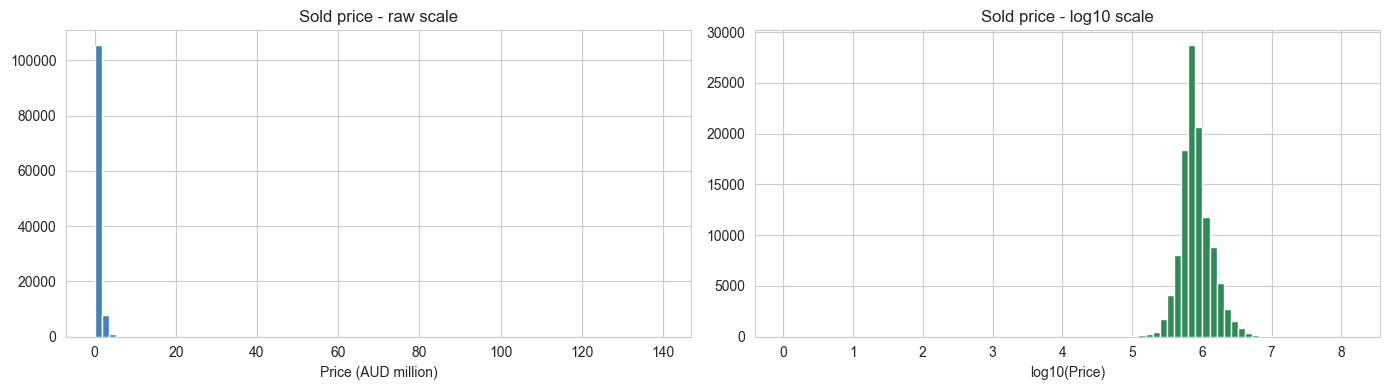

Global Numeric_Price percentiles (Sold):
count       114624.0
mean        965566.0
std        1067423.0
min              1.0
0.1%        110000.0
1%          255000.0
5%          378000.0
95%        2100000.0
99%        3650000.0
99.9%      8150000.0
max      140000000.0
Name: Numeric_Price, dtype: float64


In [12]:
sold_priced = df_sold.dropna(subset=["Numeric_Price"]).copy()

# Two-panel histogram: raw scale shows the right tail, log10 shows distribution shape.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(sold_priced["Numeric_Price"] / 1e6, bins=80, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Price (AUD million)"); axes[0].set_title("Sold price - raw scale")
axes[1].hist(np.log10(sold_priced["Numeric_Price"]), bins=80, color="seagreen", edgecolor="white")
axes[1].set_xlabel("log10(Price)"); axes[1].set_title("Sold price - log10 scale")
plt.tight_layout(); plt.show()

print("Global Numeric_Price percentiles (Sold):")
print(sold_priced["Numeric_Price"].describe(percentiles=[.001, .01, .05, .95, .99, .999]).round(0))

The raw histogram is dominated by one extreme bar around zero because of the $140M maximum; the log10 view shows a clean roughly-normal distribution centered around log10 ≈ 5.8 (i.e. ~$630k), which confirms `log1p(Price)` is the right ML target.

The global percentiles show the tails are sharp: minimum is $1 (clearly not a real transaction), 99.9th percentile is $8.15M, and the maximum is $140M. Per-type IQR ceilings (e.g. House ≈ $2.7M, Apartment ≈ $1.47M) are tight and would discard many legitimate luxury sales, so I use them only as context, not as hard bounds.

I set hard bounds at $50,000 floor and $20,000,000 ceiling. This removes only ~100-150 rows in the deep tails, none of which are recoverable.

**Physical attribute outliers**

Beds, Baths, Car_Spaces should follow human-scale property logic. Values above 10 are almost always typos. I count suspicious patterns; cleaning is applied in one batch at the end of Section 3.

In [13]:
# Distribution and tail counts on Beds, Baths, Car_Spaces in the Sold set.
print("Beds distribution (Sold):")
print(df_sold["Beds"].describe().round(2))
print(f"  Beds > 10: {(df_sold['Beds'] > 10).sum()} rows")
print(f"  Beds = 0 AND not flagged as land: "
      f"{((df_sold['Beds'] == 0) & (df_sold['is_land'] == 0)).sum()} rows")

print("\nBaths distribution (Sold):")
print(df_sold["Baths"].describe().round(2))
print(f"  Baths > 10: {(df_sold['Baths'] > 10).sum()} rows")
print(f"  Baths > Beds*2 (with Beds > 0): "
      f"{((df_sold['Baths'] > df_sold['Beds']*2) & (df_sold['Beds'] > 0)).sum()} rows")

print("\nCar_Spaces distribution (Sold):")
print(df_sold["Car_Spaces"].describe().round(2))
print(f"  Car_Spaces > 10: {(df_sold['Car_Spaces'] > 10).sum()} rows")

# Same checks on For Sale, since the same caps will be applied to inference inputs.
print("\n--- For Sale ---")
print(f"Beds > 10:                                 {(df_forsale['Beds'] > 10).sum()}")
print(f"Beds = 0 AND not flagged as land:          "
      f"{((df_forsale['Beds'] == 0) & (df_forsale['is_land'] == 0)).sum()}")
print(f"Baths > Beds*2 (with Beds > 0):            "
      f"{((df_forsale['Baths'] > df_forsale['Beds']*2) & (df_forsale['Beds'] > 0)).sum()}")
print(f"Car_Spaces > 10:                           {(df_forsale['Car_Spaces'] > 10).sum()}")

Beds distribution (Sold):
count    124850.00
mean          3.14
std           1.29
min           0.00
25%           3.00
50%           3.00
75%           4.00
max          30.00
Name: Beds, dtype: float64
  Beds > 10: 56 rows
  Beds = 0 AND not flagged as land: 227 rows

Baths distribution (Sold):
count    124850.00
mean          1.75
std           0.85
min           0.00
25%           1.00
50%           2.00
75%           2.00
max          20.00
Name: Baths, dtype: float64
  Baths > 10: 18 rows
  Baths > Beds*2 (with Beds > 0): 4 rows

Car_Spaces distribution (Sold):
count    124850.00
mean          2.07
std          33.85
min           0.00
25%           1.00
50%           2.00
75%           2.00
max       11951.00
Name: Car_Spaces, dtype: float64
  Car_Spaces > 10: 277 rows

--- For Sale ---
Beds > 10:                                 23
Beds = 0 AND not flagged as land:          95
Baths > Beds*2 (with Beds > 0):            0
Car_Spaces > 10:                           99


Beds and Car_Spaces both contain absurd values (Beds max=30, Car_Spaces max=11,951). I cap each at 10. The 227 Sold rows with Beds=0 on non-land are dominated by House (102) and Rural (39) - these will be set to NaN for ML imputation rather than kept as zero, because zero is not a plausible value for a house. The 4 Baths > Beds*2 cases are negligible and will be capped.

**LandSize outliers**

LandSize has two failure modes. Zero LandSize is normal for Apartment-like and Townhouse types (they typically share or have no individual land), but anomalous for House, Villa, Rural, Acreage, etc. Per-type analysis is needed because acreage can legitimately have hundreds of thousands of sqm while a House should not exceed roughly 50,000 sqm.

In [14]:
# LandSize percentiles to inform the cap level.
print("LandSize_sqm percentiles (Sold, all rows):")
print(df_sold["LandSize_sqm"].describe(percentiles=[.5, .9, .99, .999]).round(0))

# Zero LandSize on non-apartment, non-land property types.
APT_LIKE = {"Apartment / Unit / Flat", "Studio", "Penthouse",
            "Block of Units", "Car Space"}

bad_zero_sold = (df_sold["LandSize_sqm"] == 0) & \
                (~df_sold["Property_Type"].isin(APT_LIKE)) & \
                (df_sold["is_land"] == 0)
bad_zero_fs   = (df_forsale["LandSize_sqm"] == 0) & \
                (~df_forsale["Property_Type"].isin(APT_LIKE)) & \
                (df_forsale["is_land"] == 0)

print(f"\nLandSize=0 on non-apartment, non-land rows:")
print(f"  Sold:     {bad_zero_sold.sum():,}")
print(f"  For Sale: {bad_zero_fs.sum():,}")

# Top-tail look: largest LandSize values among non-land rows.
print("\nTop 10 largest LandSize_sqm among non-land Sold rows:")
print(df_sold[df_sold["is_land"] == 0]
      .nlargest(10, "LandSize_sqm")[["Property_Type", "Suburb", "LandSize_sqm", "Numeric_Price"]]
      .to_string(index=False))

LandSize_sqm percentiles (Sold, all rows):
count       124850.0
mean          5289.0
std         565297.0
min              0.0
50%            448.0
90%           1184.0
99%          68796.0
99.9%       449200.0
max      197433984.0
Name: LandSize_sqm, dtype: float64

LandSize=0 on non-apartment, non-land rows:
  Sold:     25,102
  For Sale: 7,776

Top 10 largest LandSize_sqm among non-land Sold rows:
       Property_Type     Suburb  LandSize_sqm  Numeric_Price
               House    GRUYERE   197433984.0      2420000.0
               House   MYRNIONG    17178100.0      1425000.0
               House  KURUNJANG     8093700.0       412500.0
               House   SORRENTO     5876000.0      1520000.0
               House     YERING     2060000.0      6500000.0
               Rural     YERING     2023400.0      8305000.0
               Rural    SUNBURY     1841300.0            NaN
               House    SUNBURY     1529700.0            NaN
Acreage / Semi-Rural CONNEWARRE     1397300.0  

Two serious LandSize problems are visible.

First, 25,102 Sold rows (20% of the data) have LandSize=0 on property types that should have land - dominated by House (18,568) and Townhouse (5,883). This is a systemic scraping gap, not random noise. Setting all 25k to NaN would force ML to impute 20% of the column; setting them to per-type medians during cleaning is more honest because it acknowledges the gap explicitly. I will impute these now using per-Property_Type median LandSize computed only on rows with positive land area.

Second, the top of the LandSize distribution contains clear Property_Type misclassifications: a "House" with 197 million sqm in GRUYERE, another "House" with 17 million sqm. The 99% percentile for House is 51,800 sqm but 99.9% is 302,051 sqm - the gap is 6x. I apply per-Property_Type caps using the 99% percentile (computed on positive values) for House/Townhouse/Villa, and the 99.9% percentile for Acreage/Rural/Farm (where extreme values are legitimate). This is tighter than a global cap and respects the natural land-size scale of each type.

**Geographic outliers**

I define a Melbourne metro envelope of approximately:

- Latitude: -38.6 to -37.4
- Longitude: 144.4 to 145.7

Properties outside this envelope are not necessarily errors. Domain.com.au lists genuinely regional properties (Geelong, Ballarat, Mornington Peninsula extensions, etc.) that are legitimately outside the inner metro box. I therefore flag rather than drop. The flag (`out_of_metro`) lets downstream geospatial visualizations focus on the metro core while still keeping regional rows in the modeling set.

In [15]:
# Count and inspect rows outside the Melbourne metro envelope.
LAT_MIN, LAT_MAX = -38.6, -37.4
LON_MIN, LON_MAX = 144.4, 145.7

geo_out_sold = df_sold[(~df_sold["Latitude"].between(LAT_MIN, LAT_MAX)) |
                       (~df_sold["Longitude"].between(LON_MIN, LON_MAX))]
geo_out_fs   = df_forsale[(~df_forsale["Latitude"].between(LAT_MIN, LAT_MAX)) |
                          (~df_forsale["Longitude"].between(LON_MIN, LON_MAX))]

print(f"Rows outside Melbourne metro envelope:")
print(f"  Sold:     {len(geo_out_sold):,}  ({len(geo_out_sold)/len(df_sold)*100:.1f}%)")
print(f"  For Sale: {len(geo_out_fs):,}  ({len(geo_out_fs)/len(df_forsale)*100:.1f}%)")

# Show a few examples to confirm these look like real regional listings rather than coordinate errors.
print("\nExamples of out-of-metro Sold rows:")
print(geo_out_sold[["Suburb", "Postcode", "Latitude", "Longitude", "Distance_to_CBD_km"]]
      .head(8).to_string(index=False))

Rows outside Melbourne metro envelope:
  Sold:     4,334  (3.5%)
  For Sale: 1,804  (4.7%)

Examples of out-of-metro Sold rows:
  Suburb  Postcode   Latitude  Longitude  Distance_to_CBD_km
KOROBEIT      3341 -37.563847  144.35050               60.64
MYRNIONG      3341 -37.562230  144.36299               59.75
MYRNIONG      3341 -37.560963  144.36370               59.76
MYRNIONG      3341 -37.565270  144.35516               60.20
MYRNIONG      3341 -37.562454  144.35805               60.12
KOROBEIT      3341 -37.565807  144.35326               60.32
MYRNIONG      3341 -37.560352  144.36017               60.06
MYRNIONG      3341 -37.577910  144.35915               59.25


**Apply outlier handling**

Rules applied to both Sold and For Sale (so inference data matches training shape). Price-range rules differ between groups: Sold uses transaction prices and rows outside [$50k, $20M] are dropped because they cannot contribute to ML training. For Sale uses asking prices and rows outside the same range are NaN-ified rather than dropped, because the location/physical features are still valid inference inputs even when the asking price is unparseable.

| Issue | Action |
|---|---|
| Sold: Numeric_Price < $50k or > $20M | Drop |
| For Sale: Numeric_Price < $50k or > $20M | Set Numeric_Price to NaN, mark Raw_Price as "Contact Agent" |
| Beds > 10 | Cap at 10 |
| Baths > Beds*2 when Beds > 0 | Cap at Beds*2, then cap absolute at 10 |
| Car_Spaces > 10 | Cap at 10 |
| Beds = 0 AND not land | Set Beds and Baths to NaN for ML imputation |
| LandSize = 0 on non-apartment, non-land | Set to NaN for ML imputation |
| LandSize > per-type cap (99% for House/Townhouse/Villa; 99.9% for Acreage/Rural/Farm) | Cap |
| Lat/Lng outside metro envelope | Flag `out_of_metro` |
| Property_Type = NaN | Set to "Unknown" |

The For Sale price floor catches parser errors like "$1 deposit, balance on settlement" → $1, "From $1m" mis-parsed as $1, and "Reserve $5, contact agent" → $5. Setting these to NaN is consistent with the cell-15 finding that non-numeric Raw_Price expressions ("Contact Agent", "Auction", etc.) are already represented as Numeric_Price = NaN; this just extends the same treatment to listings where the parser produced a number but the number is implausible.

Per-type LandSize medians and caps are computed once on the Sold side (training-side parameters; For Sale must not influence them) and then applied to both groups.

In [16]:
# Per-Property_Type LandSize CAPS only, computed from Sold positive-LandSize rows.
# Imputation of NaN is left to the ML preprocessor (fit on train fold only).
RESIDENTIAL_DENSE = {"House", "Townhouse", "Villa", "Semi-Detached",
                     "Terrace", "Duplex", "New House & Land",
                     "New Apartments / Off the Plan", "New Home Designs",
                     "Block of Units"}
RURAL_LARGE       = {"Acreage / Semi-Rural", "Rural", "Rural Lifestyle"}

land_caps = {}
for ptype in df_sold["Property_Type"].dropna().unique():
    sub = df_sold[(df_sold["Property_Type"] == ptype) &
                  (df_sold["LandSize_sqm"] > 0)]["LandSize_sqm"]
    if len(sub) < 10:
        continue
    cap_q = 0.999 if ptype in RURAL_LARGE else 0.99
    land_caps[ptype] = float(sub.quantile(cap_q))

print("Per-Property_Type LandSize caps (top 10 by cap value):")
for k, v in sorted(land_caps.items(), key=lambda x: -x[1])[:10]:
    print(f"  {k:35s} cap={v:>12,.0f}")

def clean_frame(d, is_sold):
    """Apply outlier handling rules. is_sold=True additionally drops price extremes."""
    d = d.copy()

    # Property_Type: NaN -> "Unknown".
    d["Property_Type"] = d["Property_Type"].fillna("Unknown")

    # Cap Beds and Car_Spaces at 10.
    d["Beds"]       = d["Beds"].clip(upper=10)
    d["Car_Spaces"] = d["Car_Spaces"].clip(upper=10)

    # Baths: cap at Beds*2 when Beds > 0, then absolute cap at 10.
    mask_baths = (d["Beds"] > 0) & (d["Baths"] > d["Beds"] * 2)
    d.loc[mask_baths, "Baths"] = d.loc[mask_baths, "Beds"] * 2
    d["Baths"] = d["Baths"].clip(upper=10)

    # Beds=0 on non-land: set Beds and Baths to NaN for ML imputation.
    mask_no_rooms = (d["Beds"] == 0) & (d["is_land"] == 0)
    d.loc[mask_no_rooms, ["Beds", "Baths"]] = np.nan

    # LandSize=0 on non-apartment, non-land -> NaN for ML imputation.
    bad_zero = (d["LandSize_sqm"] == 0) & \
               (~d["Property_Type"].isin(APT_LIKE)) & \
               (d["is_land"] == 0)
    d.loc[bad_zero, "LandSize_sqm"] = np.nan

    # LandSize upper cap per Property_Type.
    for ptype, cap in land_caps.items():
        mask_cap = (d["Property_Type"] == ptype) & (d["LandSize_sqm"] > cap)
        d.loc[mask_cap, "LandSize_sqm"] = cap

    # Flag (do not drop) out-of-metro rows.
    d["out_of_metro"] = ((~d["Latitude"].between(LAT_MIN, LAT_MAX)) |
                        (~d["Longitude"].between(LON_MIN, LON_MAX))).astype(int)

    if is_sold:
        # Sold: drop unrecoverable price extremes; keep Price Withheld (NaN) rows for descriptive use.
        priced = d["Numeric_Price"].notna()
        keep = (~priced) | (d["Numeric_Price"].between(50_000, 20_000_000))
        before = len(d)
        d = d[keep].copy()
        print(f"  Sold: dropped {before - len(d):,} rows with price < 50k or > 20M.")
    else:
        # For Sale: NaN-ify implausible asking prices instead of dropping the row.
        # These are upstream parser errors on non-numeric Raw_Price ("$1 deposit",
        # "From $1m" mis-parsed as $1, "Reserve $5", etc.). The row's location and
        # physical features are still valid inference inputs; only the asking price
        # is unrecoverable. We mark Raw_Price as "Contact Agent" so downstream
        # consumers treat these uniformly with the existing non-numeric rows.
        priced = d["Numeric_Price"].notna()
        bad_price = priced & (~d["Numeric_Price"].between(50_000, 20_000_000))
        n_bad = bad_price.sum()
        if n_bad > 0:
            d.loc[bad_price, "Numeric_Price"] = np.nan
            d.loc[bad_price, "Raw_Price"]     = "Contact Agent"
            print(f"  For Sale: NaN-ified {n_bad:,} rows with parser-error prices (< 50k or > 20M).")
        else:
            print("  For Sale: no rows with out-of-range prices.")

    return d

print("\nCleaning Sold:")
df_sold = clean_frame(df_sold, is_sold=True)
print(f"  Final size: {len(df_sold):,}")

print("\nCleaning For Sale:")
df_forsale = clean_frame(df_forsale, is_sold=False)
print(f"  Final size: {len(df_forsale):,}")

# Post-clean sanity checks.
print("\nPost-clean sanity:")
print(f"  Sold Beds max:                  {df_sold['Beds'].max()}")
print(f"  Sold Baths max:                 {df_sold['Baths'].max()}")
print(f"  Sold Car_Spaces max:            {df_sold['Car_Spaces'].max()}")
print(f"  Sold LandSize max:              {df_sold['LandSize_sqm'].max():,.0f}")
print(f"  Sold price range:               {df_sold['Numeric_Price'].min():,.0f} - "
      f"{df_sold['Numeric_Price'].max():,.0f}")
print(f"  Sold Beds NaN (rooms-less):     {df_sold['Beds'].isna().sum():,}")
print(f"  Sold LandSize NaN (was 0):      {df_sold['LandSize_sqm'].isna().sum():,}")
print(f"  For Sale LandSize NaN (was 0):  {df_forsale['LandSize_sqm'].isna().sum():,}")
print(f"  out_of_metro Sold:              {df_sold['out_of_metro'].mean()*100:.1f}%")
print(f"  out_of_metro For Sale:          {df_forsale['out_of_metro'].mean()*100:.1f}%")

Per-Property_Type LandSize caps (top 10 by cap value):
  Rural                               cap=   1,956,387
  Acreage / Semi-Rural                cap=   1,330,778
  Farm                                cap=     842,160
  Rural Lifestyle                     cap=     632,469
  Villa                               cap=     263,045
  Vacant land                         cap=     213,926
  House                               cap=      51,860
  Development Site                    cap=      45,532
  New land                            cap=      12,048
  Apartment / Unit / Flat             cap=       5,414

Cleaning Sold:
  Sold: dropped 30 rows with price < 50k or > 20M.
  Final size: 124,820

Cleaning For Sale:
  For Sale: NaN-ified 63 rows with parser-error prices (< 50k or > 20M).
  Final size: 38,419

Post-clean sanity:
  Sold Beds max:                  10.0
  Sold Baths max:                 10.0
  Sold Car_Spaces max:            10
  Sold LandSize max:              1,956,387
  Sold price 

## 4. Univariate Analysis

I examine each variable in isolation. For attributes shared by both groups (Beds, LandSize, Property_Type, Suburb, Distance_to_CBD), I plot Sold and For Sale side-by-side to enable a visual drift check that Section 8 will quantify formally with statistical tests.

Price is the only Sold-only analysis here, because For Sale has no transaction price. I plot it on both raw and log1p scales to confirm the right-skew that justifies `log1p(Price)` as the ML target.


### 4.1 Sold price distribution

I use Numeric_Price filtered to non-NaN rows only (i.e. excluding the ~10k Price Withheld rows). I show both raw and log1p views and report key percentiles.

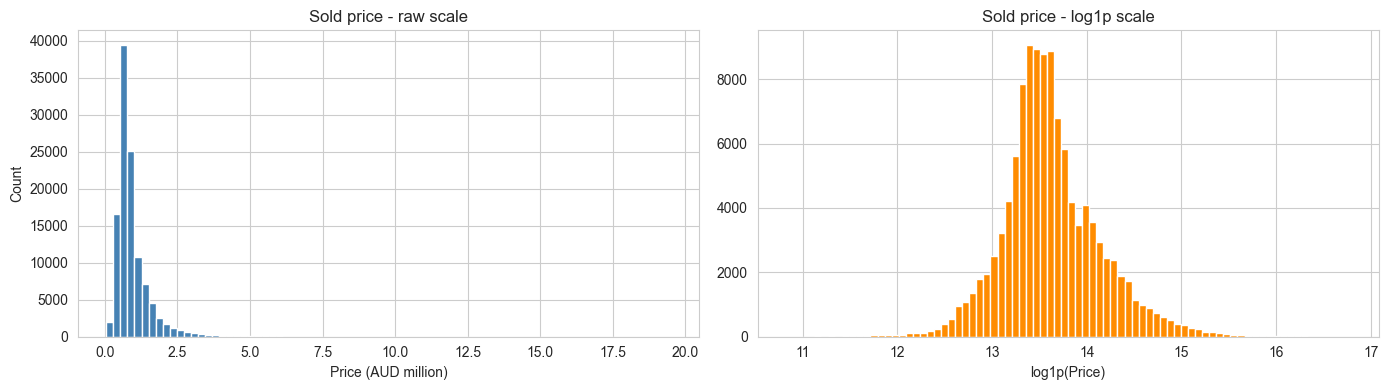

Sold Numeric_Price summary (n=114,594):
count      114594.0
mean       958510.0
std        701764.0
min         50000.0
5%         378500.0
25%        610000.0
50%        772295.0
75%       1081545.0
95%       2100000.0
99%       3630140.0
max      19500000.0
Name: Numeric_Price, dtype: float64


In [16]:
# Work on Sold rows that have a usable transaction price.
sold_priced = df_sold.dropna(subset=["Numeric_Price"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw scale in AUD million.
axes[0].hist(sold_priced["Numeric_Price"] / 1e6, bins=80,
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Price (AUD million)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sold price - raw scale")

# log1p scale to reveal distribution shape.
axes[1].hist(np.log1p(sold_priced["Numeric_Price"]), bins=80,
             color="darkorange", edgecolor="white")
axes[1].set_xlabel("log1p(Price)")
axes[1].set_title("Sold price - log1p scale")

plt.tight_layout(); plt.show()

print("Sold Numeric_Price summary (n={:,}):".format(len(sold_priced)))
print(sold_priced["Numeric_Price"].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(0))

Observations on Sold price distribution:

- Raw scale is sharply right-skewed; log1p scale is approximately bell-shaped and roughly symmetric. This confirms `log1p(Numeric_Price)` as the ML target.

- Median = $772,295, 95th = $2.1M, 99th = $3.63M. The 99th percentile being only $3.63M confirms the $20M ceiling from Section 3 was conservative.

- Mean ($959k) exceeds median ($772k), confirming right-skew even after capping. Median-based summaries are used throughout the rest of the notebook.

### 4.2 Physical attributes - side by side

Beds, Baths, Car_Spaces, and LandSize are compared between Sold and For Sale. I use the same x-axis bins on both panels so the eye can directly compare shapes. LandSize is plotted on log1p scale because it spans from ~100 sqm (apartments) to ~1.9M sqm (rural) - a linear scale would compress everything into one bar.

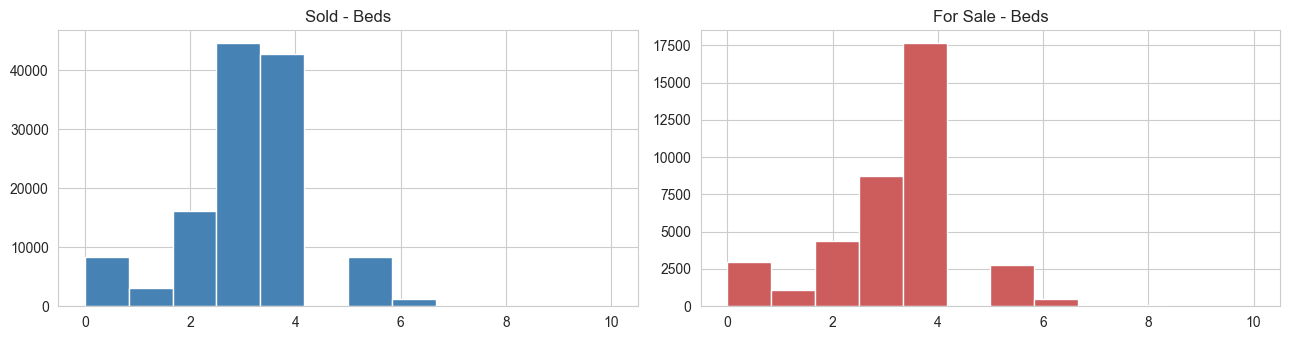

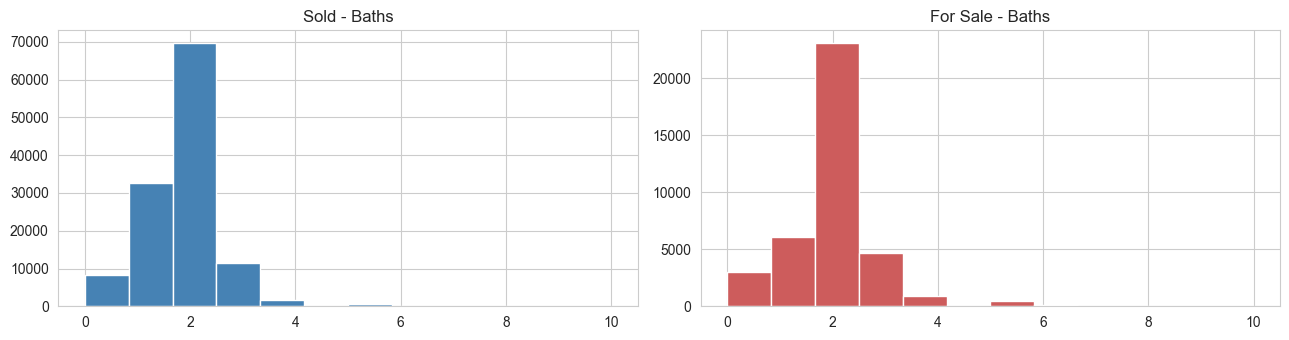

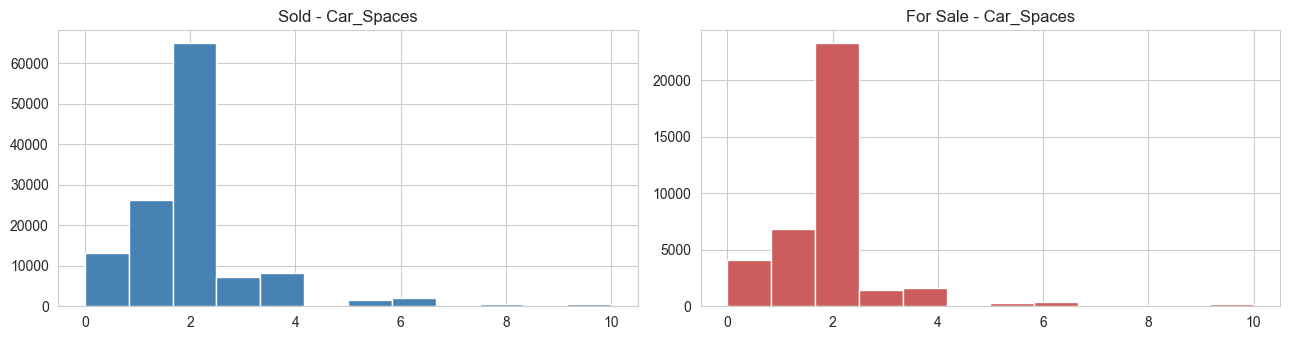

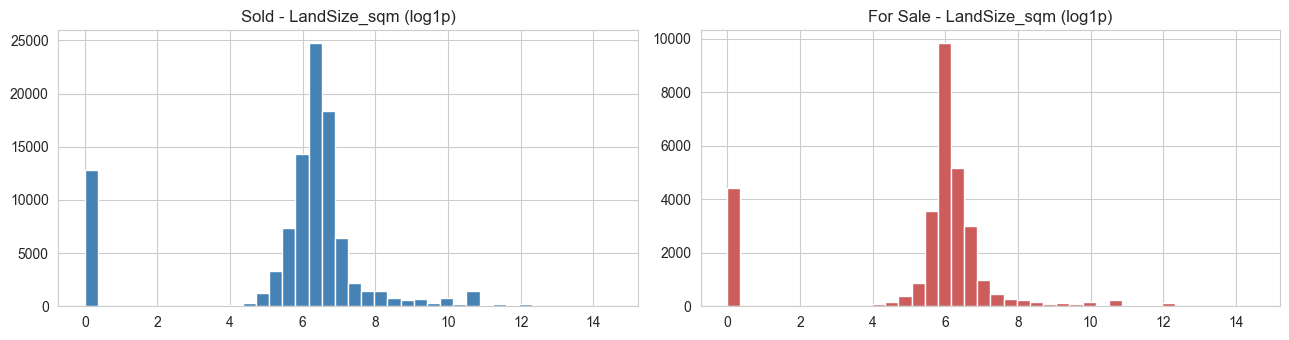

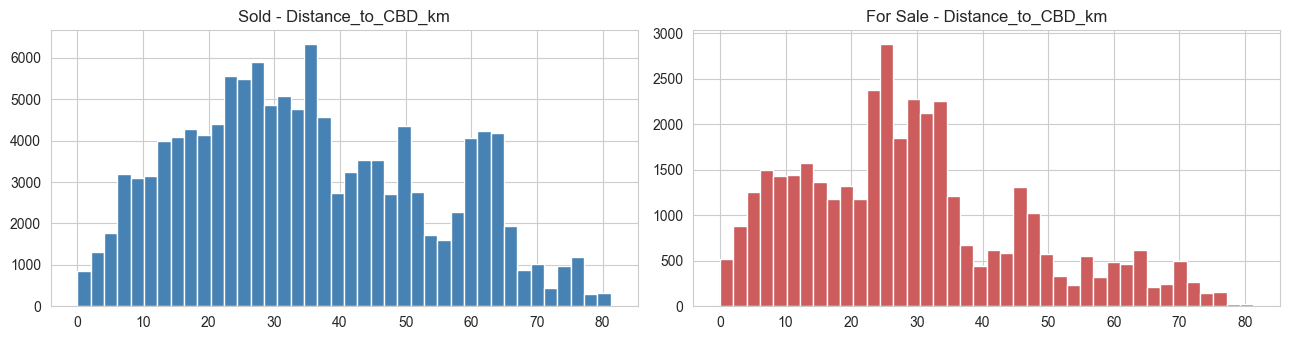

In [17]:
def side_by_side(col, bins=30, log=False, drop_na=True):
    """Plot Sold and For Sale distributions of `col` on a shared scale."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

    a = df_sold[col].dropna() if drop_na else df_sold[col]
    b = df_forsale[col].dropna() if drop_na else df_forsale[col]
    if log:
        a, b = np.log1p(a), np.log1p(b)

    # Shared bin edges for fair visual comparison.
    edges = np.histogram_bin_edges(np.concatenate([a, b]), bins=bins)

    axes[0].hist(a, bins=edges, color="steelblue",  edgecolor="white")
    axes[0].set_title(f"Sold - {col}{' (log1p)' if log else ''}")
    axes[1].hist(b, bins=edges, color="indianred",  edgecolor="white")
    axes[1].set_title(f"For Sale - {col}{' (log1p)' if log else ''}")
    plt.tight_layout(); plt.show()

side_by_side("Beds",                bins=12)
side_by_side("Baths",               bins=12)
side_by_side("Car_Spaces",          bins=12)
side_by_side("LandSize_sqm",        bins=40, log=True)
side_by_side("Distance_to_CBD_km",  bins=40)

Observations on physical attributes (Sold vs For Sale):

- Beds, Baths, Car_Spaces: both groups peak at 3-4 / 2 / 2 respectively. For Sale leans more tightly to 4 beds, 2 baths, 2 cars - consistent with standardized new-build packages.

- LandSize (log1p): bimodal in both groups - one bar near zero (NaN-rendered-as-0 plus apartment rows) and a main bell at log1p ≈ 6.3 (~550 sqm typical lot).

- Distance_to_CBD: Sold spreads broadly across 0-80 km with multiple peaks. For Sale is concentrated at 25-35 km (growth corridors) with notably less supply in the 40-65 km range.

### 4.3 Property_Type composition

I compare the share (percentage) of each Property_Type across the two groups rather than raw counts, because Sold has ~3x as many rows as For Sale. I show the top 12 types side-by-side.

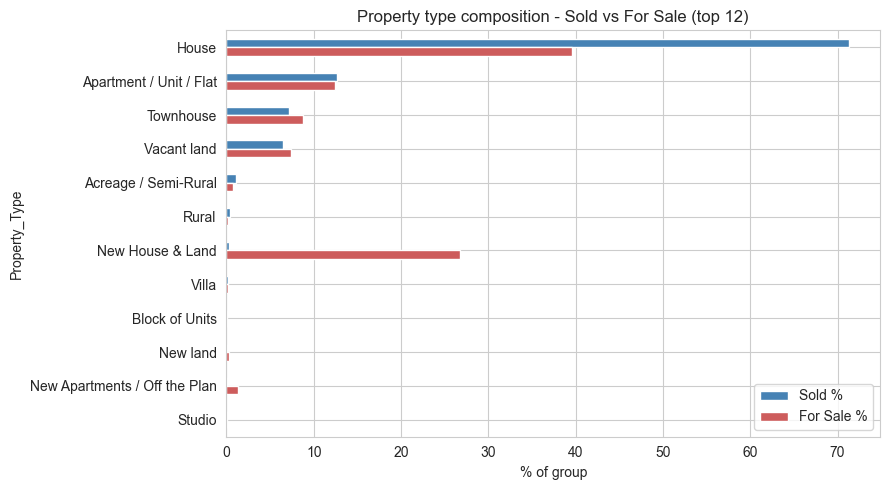

                               Sold %  For Sale %
Property_Type                                    
House                           71.30       39.64
Apartment / Unit / Flat         12.69       12.42
Townhouse                        7.20        8.74
Vacant land                      6.52        7.40
Acreage / Semi-Rural             1.04        0.73
Rural                            0.40        0.20
New House & Land                 0.27       26.75
Villa                            0.23        0.22
Block of Units                   0.08        0.11
New land                         0.08        0.26
New Apartments / Off the Plan    0.05        1.35
Studio                           0.04        0.10


In [18]:
def type_share(d, name):
    return (d["Property_Type"].value_counts(normalize=True) * 100).rename(name)

types = pd.concat([type_share(df_sold,    "Sold %"),
                   type_share(df_forsale, "For Sale %")], axis=1).fillna(0)
types = types.sort_values("Sold %", ascending=False).head(12)

types.plot(kind="barh", figsize=(9, 5), color=["steelblue", "indianred"])
plt.gca().invert_yaxis()
plt.title("Property type composition - Sold vs For Sale (top 12)")
plt.xlabel("% of group")
plt.tight_layout(); plt.show()

print(types.round(2))

Observations on Property_Type composition:

- House: 71.3% Sold vs 39.6% For Sale (32-point gap).

- "New House & Land": 0.27% Sold vs 26.75% For Sale (100x). This is the largest single drift in the dataset.

- "New Apartments / Off the Plan" (0.05% vs 1.35%) and "New land" (0.08% vs 0.26%) show the same pattern.

- All other types are roughly aligned between groups.

Cause: new-construction packages dominate listings but, once resold years later, are recorded under their physical type ("House", "Apartment"). The For Sale snapshot overweights new-build categories the ML model trained on Sold will rarely have seen.

Mitigation for ML: I will add an `is_new_build` flag grouping the four new-build categories, so the model can learn a new-build premium without depending on rare training categories.

### 4.4 Top suburbs

The two top-15 suburb lists indicate where activity is concentrated in each group. Differences may reflect normal market dynamics (some suburbs turn over faster than they list) rather than data issues.

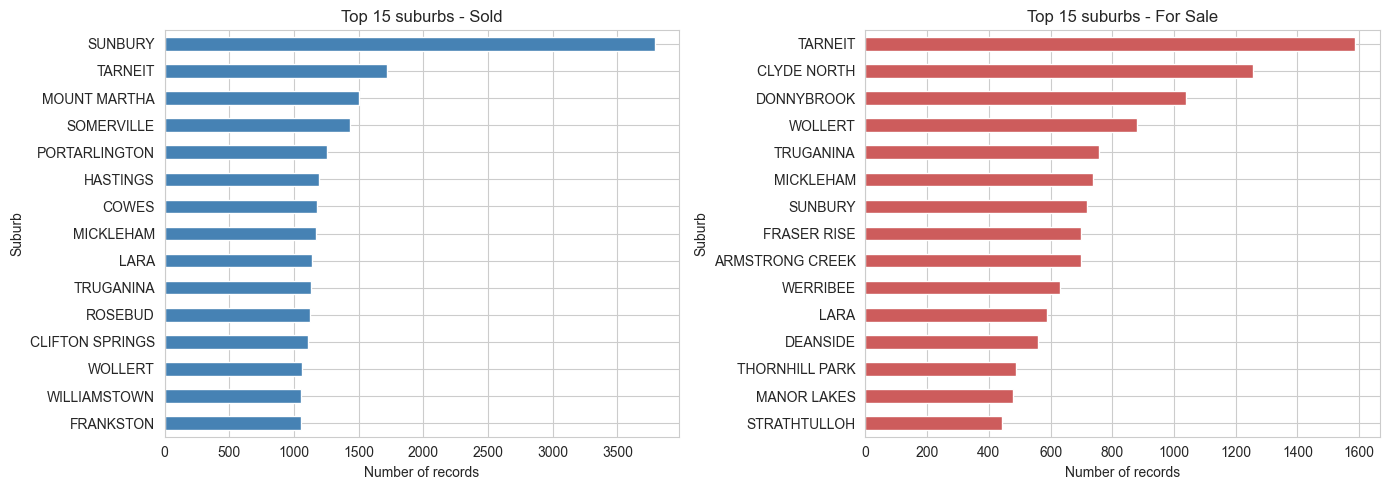

Unique suburbs in Sold:     543
Unique suburbs in For Sale: 527


In [19]:
top_sub_sold = df_sold["Suburb"].value_counts().head(15)
top_sub_fs   = df_forsale["Suburb"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_sub_sold.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Top 15 suburbs - Sold")
axes[0].set_xlabel("Number of records")

top_sub_fs.plot(kind="barh", ax=axes[1], color="indianred")
axes[1].invert_yaxis()
axes[1].set_title("Top 15 suburbs - For Sale")
axes[1].set_xlabel("Number of records")

plt.tight_layout(); plt.show()

# Total unique suburbs in each group for context.
print(f"Unique suburbs in Sold:     {df_sold['Suburb'].nunique():,}")
print(f"Unique suburbs in For Sale: {df_forsale['Suburb'].nunique():,}")

Observations on suburbs:

- 543 unique in Sold, 527 in For Sale. Section 8 will check overlap.

- For Sale top suburbs are almost all outer-ring growth corridors (TARNEIT, CLYDE NORTH, DONNYBROOK, WOLLERT, MICKLEHAM, FRASER RISE, etc.), matching the new-build supply concentration.

- Sold top suburbs are more diverse, including established coastal/peninsula suburbs (MOUNT MARTHA, COWES, PORTARLINGTON, ROSEBUD) absent from the For Sale top list.

The ML model will face systematic input bias toward growth-corridor suburbs at inference time.

### 4.5 Sold transaction time distribution

For Sold rows I plot the year-month distribution of transactions to confirm that the data is heavily concentrated in 2023-2026, as Section 1 suggested, and to identify low-volume years that I should filter out of the time-series chart in Section 6.

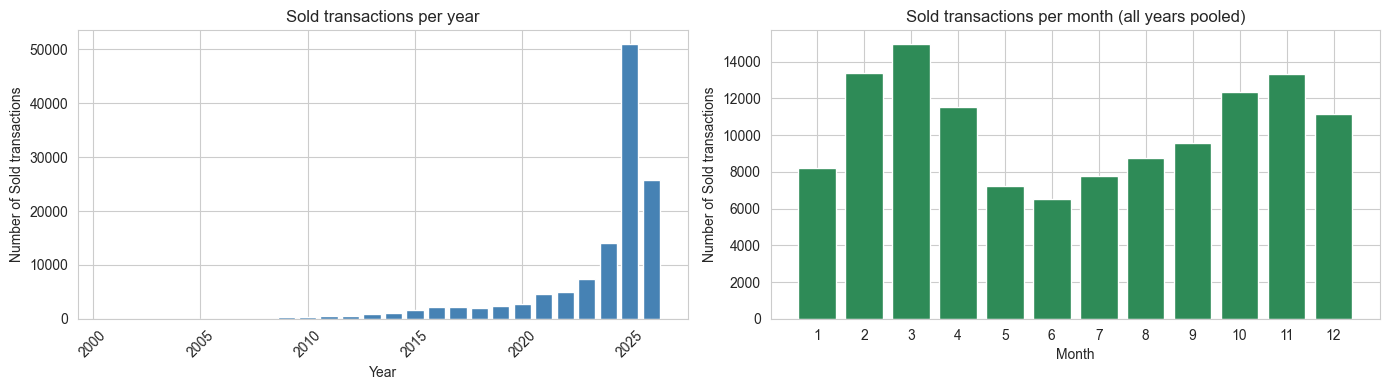

Years with fewer than 200 Sold transactions (will be filtered in Section 6):
Year
2001.0     1
2004.0     1
2005.0     1
2006.0     8
2007.0    35
2008.0    47
Name: count, dtype: int64


In [20]:
# Yearly transaction count.
year_counts = df_sold["Year"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(year_counts.index, year_counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Sold transactions")
axes[0].set_title("Sold transactions per year")
axes[0].tick_params(axis="x", rotation=45)

# Monthly transaction count (pooled across years) to check seasonality.
month_counts = df_sold["Month"].value_counts().sort_index()
axes[1].bar(month_counts.index, month_counts.values, color="seagreen", edgecolor="white")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Sold transactions")
axes[1].set_title("Sold transactions per month (all years pooled)")
axes[1].set_xticks(range(1, 13))

plt.tight_layout(); plt.show()

print("Years with fewer than 200 Sold transactions (will be filtered in Section 6):")
print(year_counts[year_counts < 200])

Observations on transaction timing:

- 2025 alone holds ~51,000 transactions (40% of Sold). 2024 has ~14,000, 2023 has ~5,000. Years before 2020 are individually under 5,000.

- Six early years (2001, 2004-2008) have fewer than 200 transactions each and will be filtered out of the time-series median plot in Section 6.

- Monthly distribution shows clear seasonality: March peak (~15,000), May-June trough (~6,500). Australia's spring/autumn auction seasons. Moderate amplitude (~2x peak-to-trough), so Month adds useful but secondary signal beyond Year.

## 5. Bivariate Analysis - Price Drivers

I examine how each feature relates to price. All charts in this section use Sold rows with a valid Numeric_Price only, because For Sale has no transaction price.

The goal is to confirm which features carry signal, identify non-linear relationships, and check for multicollinearity. Insights here directly shape the ML feature set.

### 5.1 Price vs physical features

I use boxplots for discrete features (Beds, Baths) and scatter plots for continuous ones (LandSize, Distance_to_CBD). For scatters I sample 5,000 points with low alpha to avoid over-plotting, and use log1p(Price) on the y-axis so the price scale is comparable across panels.

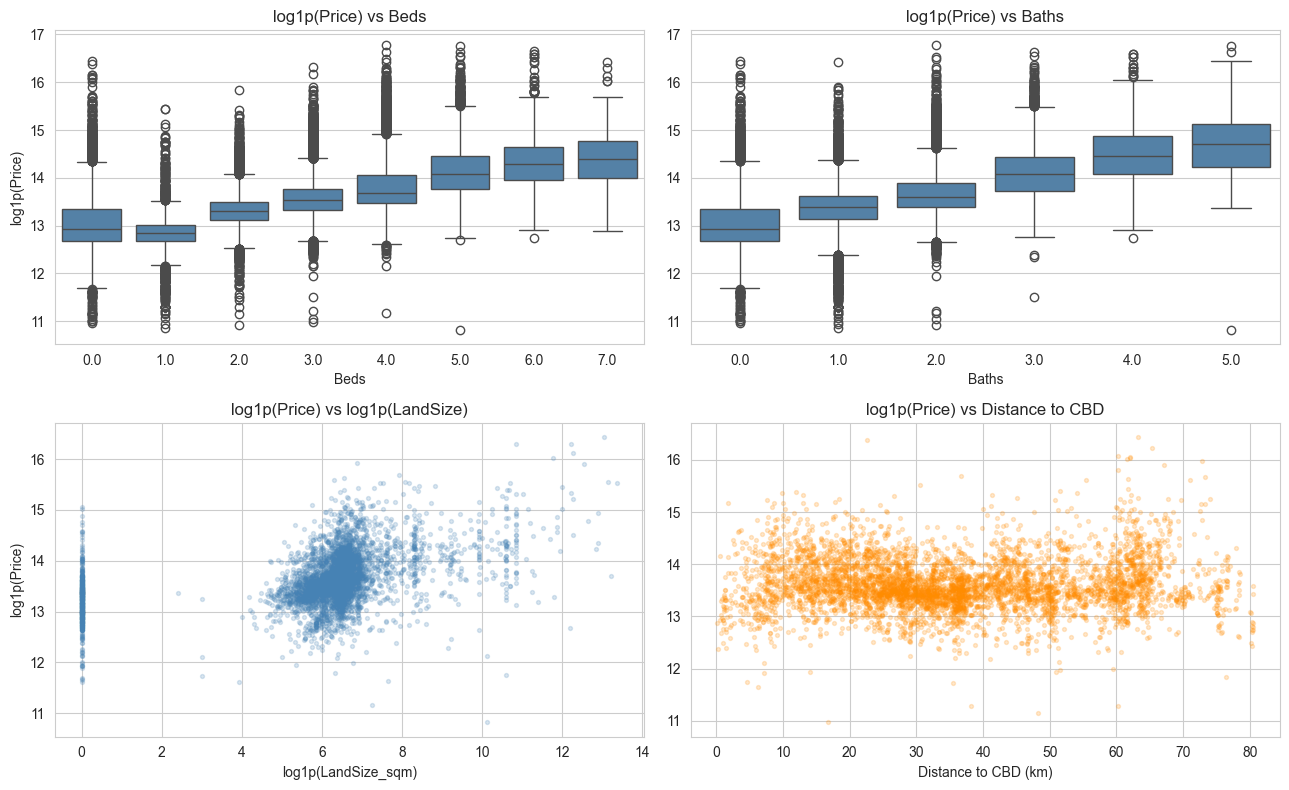

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Price vs Beds (boxplot, discrete).
sub_beds = sold_priced[sold_priced["Beds"].between(0, 7)]
sns.boxplot(x="Beds", y=np.log1p(sub_beds["Numeric_Price"]),
            data=sub_beds, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("log1p(Price) vs Beds")
axes[0,0].set_ylabel("log1p(Price)")

# Price vs Baths.
sub_baths = sold_priced[sold_priced["Baths"].between(0, 5)]
sns.boxplot(x="Baths", y=np.log1p(sub_baths["Numeric_Price"]),
            data=sub_baths, ax=axes[0,1], color="steelblue")
axes[0,1].set_title("log1p(Price) vs Baths")
axes[0,1].set_ylabel("")

# Price vs LandSize (scatter on log-log, sampled).
sample = sold_priced.dropna(subset=["LandSize_sqm"]).sample(
    min(5000, len(sold_priced.dropna(subset=["LandSize_sqm"]))), random_state=0)
axes[1,0].scatter(np.log1p(sample["LandSize_sqm"]),
                  np.log1p(sample["Numeric_Price"]),
                  alpha=0.2, s=8, color="steelblue")
axes[1,0].set_xlabel("log1p(LandSize_sqm)")
axes[1,0].set_ylabel("log1p(Price)")
axes[1,0].set_title("log1p(Price) vs log1p(LandSize)")

# Price vs Distance_to_CBD (scatter, sampled).
sample2 = sold_priced.sample(min(5000, len(sold_priced)), random_state=0)
axes[1,1].scatter(sample2["Distance_to_CBD_km"],
                  np.log1p(sample2["Numeric_Price"]),
                  alpha=0.2, s=8, color="darkorange")
axes[1,1].set_xlabel("Distance to CBD (km)")
axes[1,1].set_ylabel("")
axes[1,1].set_title("log1p(Price) vs Distance to CBD")

plt.tight_layout(); plt.show()

Observations on physical features:

- Beds and Baths: clear monotonic increase in median price from 0 to 7 beds and 0 to 5 baths. Beds=0 and Beds=1 have very similar medians (~13 on log scale), but from Beds=2 onward the relationship is strongly linear in log-space. Baths shows an even cleaner monotonic pattern. Both will be strong features.

- LandSize (log-log): two distinct populations visible. A vertical band at log1p=0 (apartments and rooms-less rows with LandSize=0) spans the full price range, while the main residential cloud at log1p(LandSize) 4-8 shows a clear positive trend. Price grows roughly linearly with log(LandSize), confirming log1p as the right transform for both axes.

- Distance_to_CBD: surprisingly weak visual relationship - the cloud is nearly flat across 0-80 km. This is because the dataset is dominated by outer-ring suburbs (15-65 km) where price varies more by suburb-specific factors than by raw distance. Distance alone will be a weak feature; the model will rely more on Latitude/Longitude and Suburb-derived features.

### 5.2 Price by Property_Type

A boxplot of log1p(Price) across the top 8 Property_Types, to confirm the type-specific price levels assumed in Section 3's outlier handling.

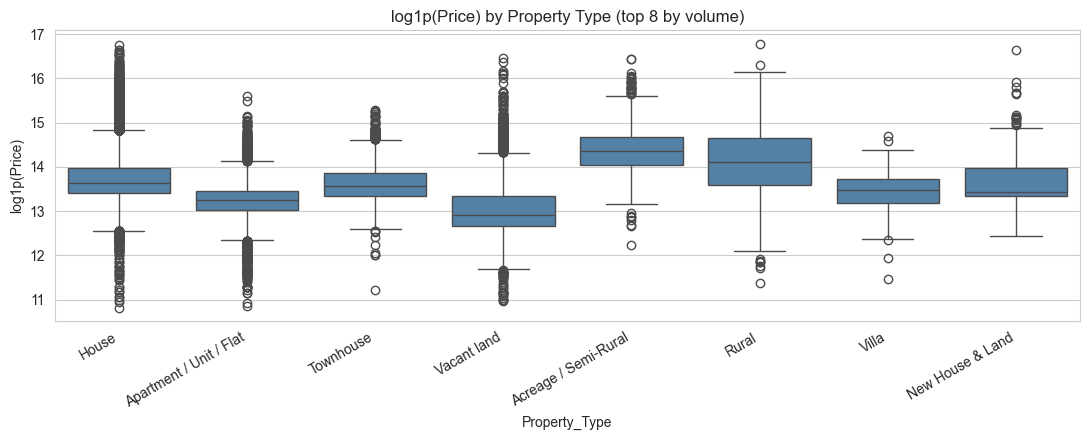

Median Numeric_Price by Property_Type (top 8):
Property_Type
Acreage / Semi-Rural       1720000.0
Rural                      1350000.0
House                       827500.0
Townhouse                   780000.0
Villa                       715000.0
New House & Land            685000.0
Apartment / Unit / Flat     570000.0
Vacant land                 410000.0
Name: Numeric_Price, dtype: float64


In [22]:
top_types = sold_priced["Property_Type"].value_counts().head(8).index
sub = sold_priced[sold_priced["Property_Type"].isin(top_types)]

plt.figure(figsize=(11, 4.5))
sns.boxplot(x="Property_Type",
            y=np.log1p(sub["Numeric_Price"]),
            data=sub,
            order=top_types,
            color="steelblue")
plt.xticks(rotation=30, ha="right")
plt.ylabel("log1p(Price)")
plt.title("log1p(Price) by Property Type (top 8 by volume)")
plt.tight_layout(); plt.show()

# Median price per type for reference.
print("Median Numeric_Price by Property_Type (top 8):")
print(sub.groupby("Property_Type")["Numeric_Price"].median().round(0).sort_values(ascending=False))

Observations on price by Property_Type:

- Acreage / Semi-Rural commands the highest median ($1.72M), followed by Rural ($1.35M). These types are land-heavy and concentrated in premium peri-urban locations.

- House ($828k) and Townhouse ($780k) form the middle tier.

- Villa ($715k), New House & Land ($685k), and Apartment ($570k) are the lower residential tier.

- Vacant land has the lowest median ($410k) - makes sense as it carries no dwelling premium.

The Property_Type ordering is consistent and will be a strong categorical feature. The model will need this distinction because the same LandSize can imply very different prices depending on type (e.g. 1,000 sqm on Vacant land vs. House).

### 5.3 Price vs socio-economic features

Suburb-level demographics (income, crime, age) are enriched onto each row. I plot their relationship with log1p(Price) to see whether they carry independent signal beyond Distance_to_CBD.

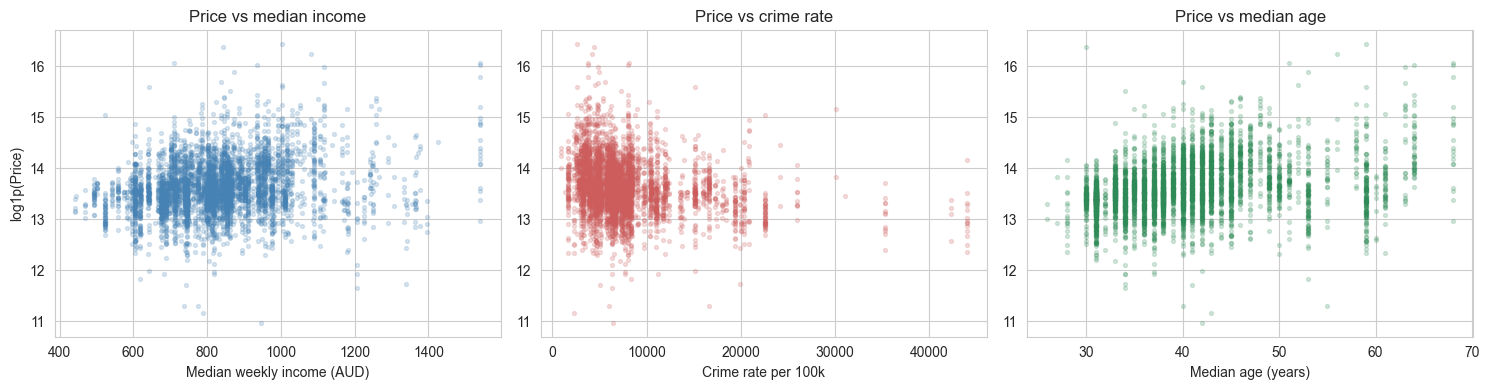

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sample once for consistency across panels.
samp = sold_priced.sample(min(5000, len(sold_priced)), random_state=0)

axes[0].scatter(samp["abs_median_income_weekly"],
                np.log1p(samp["Numeric_Price"]),
                alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("Median weekly income (AUD)")
axes[0].set_ylabel("log1p(Price)")
axes[0].set_title("Price vs median income")

axes[1].scatter(samp["crime_rate_per_100k"],
                np.log1p(samp["Numeric_Price"]),
                alpha=0.2, s=8, color="indianred")
axes[1].set_xlabel("Crime rate per 100k")
axes[1].set_title("Price vs crime rate")

axes[2].scatter(samp["abs_median_age"],
                np.log1p(samp["Numeric_Price"]),
                alpha=0.2, s=8, color="seagreen")
axes[2].set_xlabel("Median age (years)")
axes[2].set_title("Price vs median age")

plt.tight_layout(); plt.show()

Observations on socio-economic features:

- Median income: weak positive relationship. Price drifts upward as income rises but with very high variance at every income level. Income alone is not a strong predictor.

- Crime rate: weak negative trend. Most data sits at crime rates 2k-10k per 100k; the few extreme-crime suburbs (>20k) cluster at lower prices but the relationship is noisy.

- Median age: moderate positive relationship - older-population suburbs (50-65 years) tend to be more expensive, consistent with established, settled coastal/peninsula areas commanding premiums.

All three socio-economic features carry some signal but each is weak individually. The ML model should benefit from their combined contribution rather than relying on any one.

### 5.4 Correlation heatmap

A Pearson correlation matrix on the numeric features in the Sold set. I use it to verify the bivariate findings above and to spot multicollinearity, which matters for linear models in the ML notebook.

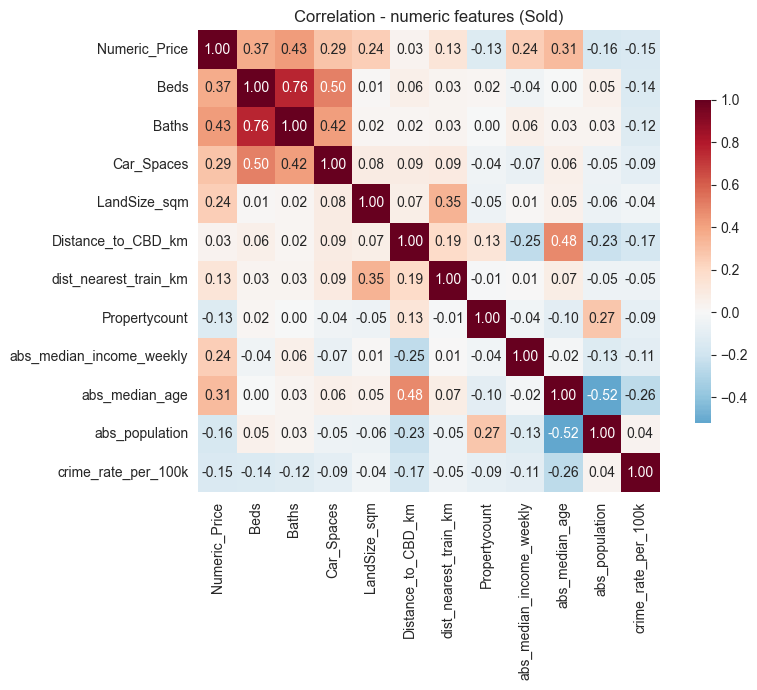

In [24]:
num_cols = ["Numeric_Price", "Beds", "Baths", "Car_Spaces", "LandSize_sqm",
            "Distance_to_CBD_km", "dist_nearest_train_km", "Propertycount",
            "abs_median_income_weekly", "abs_median_age", "abs_population",
            "crime_rate_per_100k"]

corr = sold_priced[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": .7})
plt.title("Correlation - numeric features (Sold)")
plt.tight_layout(); plt.show()

Observations on the correlation heatmap:

Price correlations (top row):

- Baths (0.43), Beds (0.37), abs_median_age (0.31), Car_Spaces (0.29), LandSize (0.24), abs_median_income_weekly (0.24) are the strongest linear correlates of price.
- Distance_to_CBD has essentially zero linear correlation (0.03) - confirming the scatter observation. The relationship is non-linear and location-dependent.
- crime_rate_per_100k (-0.15) and abs_population (-0.16) are mildly negative.

Multicollinearity to watch:

- Beds ↔ Baths: 0.76 (strong). Linear regression will need regularization (Ridge) to handle this. Tree models are unaffected.
- Beds ↔ Car_Spaces: 0.50 (moderate).
- abs_median_age ↔ abs_population: -0.52 (older suburbs are smaller).
- abs_median_age ↔ Distance_to_CBD: 0.48 (further-out suburbs are older).
- abs_median_income ↔ Distance_to_CBD: -0.25 (closer-in suburbs are richer).

Implications for ML:

- For tree-based models (RandomForest, XGBoost), all features can be included; multicollinearity does not hurt them.
- For Linear Regression baseline, I will apply Ridge regularization to stabilize coefficients given the Beds-Baths-Car_Spaces collinearity cluster.
- No feature is so dominantly correlated with price that I should treat it as an obvious primary driver - this is a multi-feature problem where the model must combine signals.

## 6. Time Series Analysis - Price Inflation

This section is the empirical justification for using Year and Month as ML features.

The ML notebook trains on Sold rows using each transaction's actual Year and Month, then at inference time injects the current Year (2026) and Month (5) into For Sale rows so predictions reflect today's market level. This design only makes sense if price actually changes materially over time. Section 6 verifies that.

I produce three views:

1. Median price per year across all property types, with transaction volume as context.
2. Median price per year broken down by Property_Type, to check whether inflation is uniform.
3. Median price per month pooled across years, to quantify seasonality.

Years with fewer than 200 transactions are excluded from the median plots, as identified in Section 4.5.

### 6.1 Median price per year (overall)

The line shows median Sold price per year. The bar overlay shows transaction volume to give the reader context on sample-size confidence: a year with thousands of transactions has a more reliable median than a year with a few hundred.

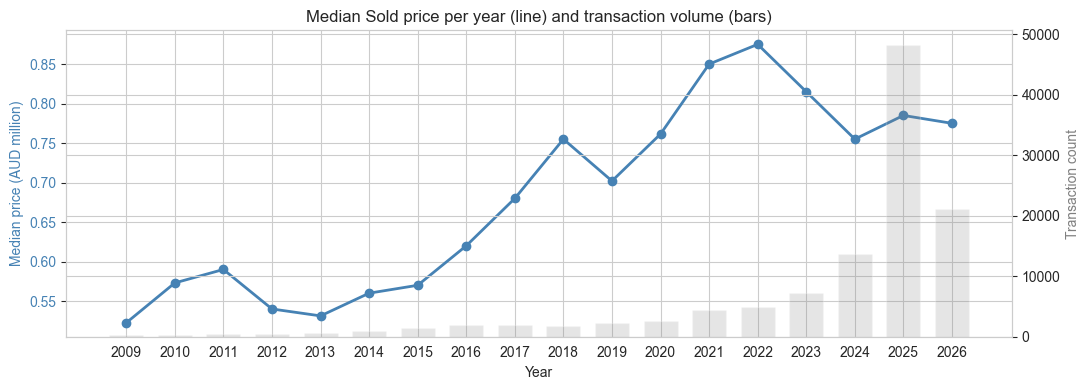

Year-over-year median price growth (years with >=200 transactions):
 Year  median_k  count  yoy_pct
 2009     522.0    208      NaN
 2010     573.0    280      9.7
 2011     590.0    373      3.0
 2012     540.0    427     -8.5
 2013     531.0    690     -1.6
 2014     560.0    983      5.4
 2015     570.0   1425      1.8
 2016     620.0   1879      8.8
 2017     680.0   1989      9.7
 2018     755.0   1825     11.0
 2019     702.0   2309     -7.0
 2020     762.0   2682      8.5
 2021     850.0   4425     11.6
 2022     875.0   4852      2.9
 2023     815.0   7196     -6.9
 2024     755.0  13652     -7.4
 2025     785.0  48234      4.0
 2026     775.0  21086     -1.3


In [25]:
# Group by year, keep only years with adequate sample size.
ts = (sold_priced
      .groupby("Year")["Numeric_Price"]
      .agg(["median", "count"])
      .reset_index())

ts = ts[ts["count"] >= 200].copy()
ts["Year"] = ts["Year"].astype(int)

fig, ax1 = plt.subplots(figsize=(11, 4))

# Median line on left y-axis.
ax1.plot(
    ts["Year"],
    ts["median"] / 1e6,
    marker="o",
    color="steelblue",
    linewidth=2
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Median price (AUD million)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Force integer year ticks (remove .0 / .5)
ax1.set_xticks(ts["Year"])

# Volume bars on right y-axis.
ax2 = ax1.twinx()
ax2.bar(
    ts["Year"],
    ts["count"],
    alpha=0.2,
    color="grey",
    width=0.7
)

ax2.set_ylabel("Transaction count", color="grey")

plt.title("Median Sold price per year (line) and transaction volume (bars)")
plt.tight_layout()
plt.show()

# Year-over-year growth table.
ts["yoy_pct"] = (ts["median"].pct_change() * 100).round(1)
ts["median_k"] = (ts["median"] / 1e3).round(0)

print("Year-over-year median price growth (years with >=200 transactions):")
print(ts[["Year", "median_k", "count", "yoy_pct"]].to_string(index=False))

Observations on yearly median price:

- Strong rise from $522k (2009) to peak $875k (2022), then pullback to $755k (2024), recovery to $785k (2025), slight softening to $775k (2026 YTD).

- YoY swings range from -8% to +12%, easily large enough that a model without Year would systematically misprice older and newer transactions.

- 2026 figure covers only Jan-2 May (~21k transactions). Volume is dominated by 2024-2026; 2025 alone has more transactions than 2009-2020 combined.

- Trajectory is non-monotonic. Tree models handle it naturally; the Linear baseline will likely underperform here.

- At inference, injecting Year = 2026 places For Sale predictions on the current price level - the correct "today-priced" reference.

### 6.2 Median price per year by Property_Type

Different property types may inflate at different rates. I plot the four highest-volume types separately. If the lines diverge sharply, the ML model will need to capture an interaction between Year and Property_Type. Tree-based models do this automatically; linear models would need an explicit interaction term.

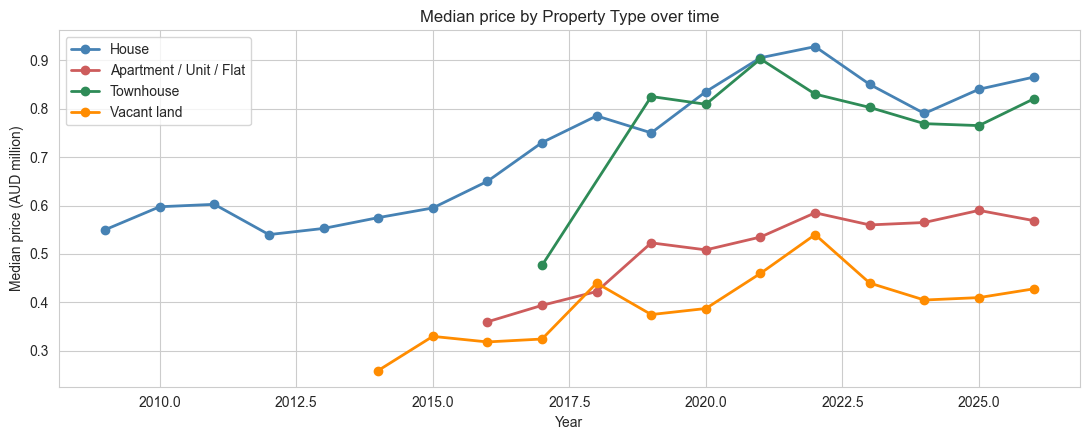

In [26]:
big_types = ["House", "Apartment / Unit / Flat", "Townhouse", "Vacant land"]

ts_t = (sold_priced[sold_priced["Property_Type"].isin(big_types)]
        .groupby(["Year", "Property_Type"])["Numeric_Price"]
        .agg(["median", "count"])
        .reset_index())
ts_t = ts_t[ts_t["count"] >= 50]   # min 50 sales per (year, type) cell

plt.figure(figsize=(11, 4.5))
colors = {"House": "steelblue", "Apartment / Unit / Flat": "indianred",
          "Townhouse": "seagreen", "Vacant land": "darkorange"}
for t in big_types:
    sub = ts_t[ts_t["Property_Type"] == t]
    plt.plot(sub["Year"], sub["median"] / 1e6,
             marker="o", label=t, color=colors[t], linewidth=2)

plt.legend()
plt.ylabel("Median price (AUD million)")
plt.xlabel("Year")
plt.title("Median price by Property Type over time")
plt.tight_layout(); plt.show()

Observations on median price per year by Property_Type:

- All four types share the same broad trajectory (rise to 2022, dip 2023-2024, recovery 2025-2026) - driven by common macro factors.

- House and Townhouse move closely. Apartment is much flatter (+58% over 10 years vs +57% for House but with lower amplitude). The House-Apartment gap widens from ~$200k (2016) to ~$300k (2026).

- A simple Year coefficient would imply uniform inflation - wrong. The model needs a Year x Property_Type interaction, which tree models capture automatically.

### 6.3 Seasonality - median price by month (pooled)

I pool all years to isolate the month-of-year effect from the year-on-year trend. A flat bar chart would mean Month adds no signal; a clear pattern would justify including it as a feature alongside Year.

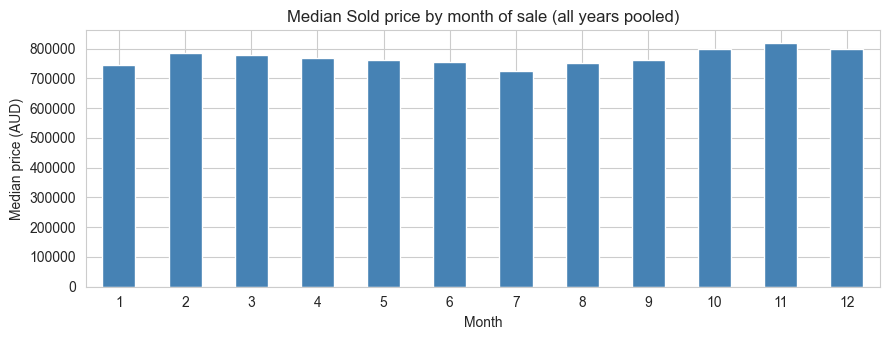

Overall median: 772,295
       median_price  vs_overall_pct
Month                              
1          745000.0            -3.5
2          786000.0             1.8
3          780000.0             1.0
4          770000.0            -0.3
5          760000.0            -1.6
6          755000.0            -2.2
7          725000.0            -6.1
8          750000.0            -2.9
9          760000.0            -1.6
10         800000.0             3.6
11         820000.0             6.2
12         800000.0             3.6


In [27]:
month_med = (sold_priced
             .groupby("Month")["Numeric_Price"]
             .median()
             .reindex(range(1, 13)))

month_med.plot(kind="bar", figsize=(9, 3.5), color="steelblue", edgecolor="white")
plt.title("Median Sold price by month of sale (all years pooled)")
plt.ylabel("Median price (AUD)")
plt.xlabel("Month")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

# Compact summary: median per month and deviation from annual median.
overall = sold_priced["Numeric_Price"].median()
month_summary = pd.DataFrame({
    "median_price": month_med.round(0),
    "vs_overall_pct": ((month_med / overall - 1) * 100).round(1),
})
print(f"Overall median: {overall:,.0f}")
print(month_summary.to_string())

Observations on median price per year by Property_Type:

- All four types share the same broad trajectory (rise to 2022, dip 2023-2024, recovery 2025-2026) - driven by common macro factors.

- House and Townhouse move closely. Apartment is much flatter (+58% over 10 years vs +57% for House but with lower amplitude). The House-Apartment gap widens from ~$200k (2016) to ~$300k (2026).

- A simple Year coefficient would imply uniform inflation - wrong. The model needs a Year x Property_Type interaction, which tree models capture automatically.

## 7. Geospatial Analysis

Geographic patterns matter even after controlling for Distance_to_CBD, because two locations the same distance from the CBD can have very different prices (e.g. inner east vs inner west). This section produces three views:

1. A spatial scatter of Sold prices, to see how price varies across the metro area.

2. A spatial scatter of For Sale supply, to confirm the growth-corridor concentration observed in Section 4.

3. Top and bottom suburbs by median price, to identify the price hierarchy that suburb-level features will need to capture.

### 7.1 Price map (Sold) and supply map (For Sale)

I sample up to 15,000 points per map to avoid over-plotting. The Sold map is colored by log1p(Price); the For Sale map is uniform color because For Sale has no transaction price - its purpose is to show where current supply is concentrated. Both are clipped to the Melbourne metro envelope for clarity.

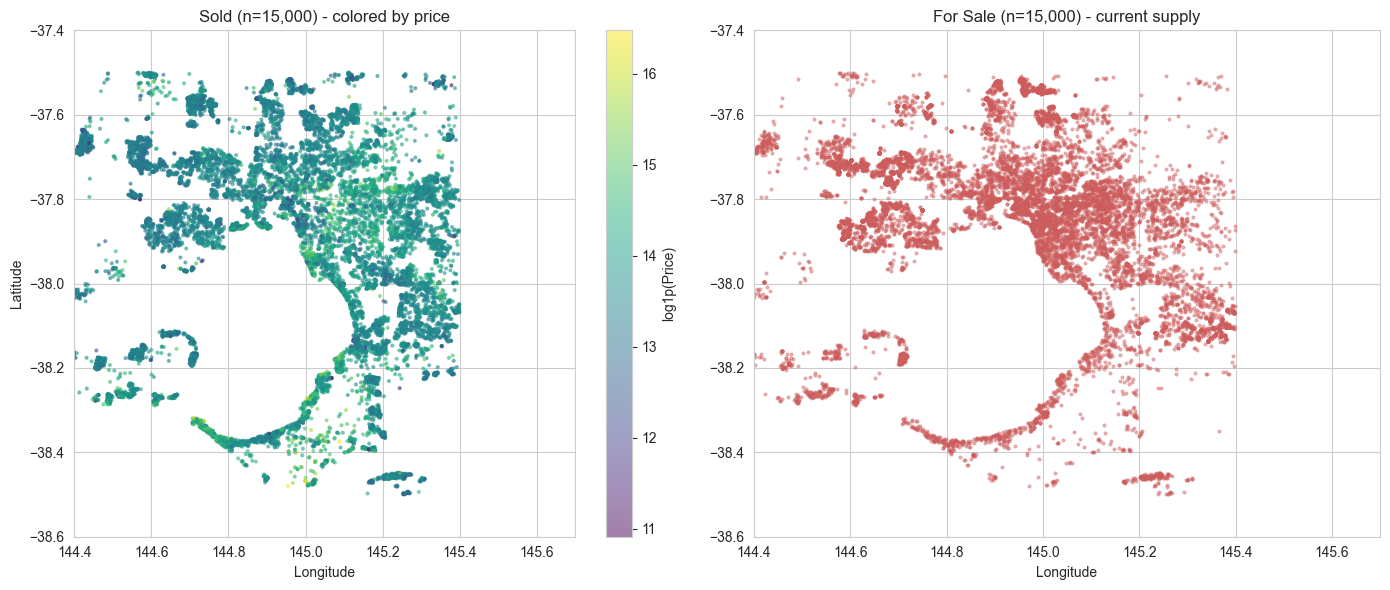

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sold map - colored by log1p(Price).
s = sold_priced.sample(min(15000, len(sold_priced)), random_state=0)
sc = axes[0].scatter(s["Longitude"], s["Latitude"],
                     c=np.log1p(s["Numeric_Price"]),
                     cmap="viridis", s=4, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label="log1p(Price)")
axes[0].set_title(f"Sold (n={len(s):,}) - colored by price")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# For Sale map - uniform color, shows current supply distribution.
f = df_forsale.sample(min(15000, len(df_forsale)), random_state=0)
axes[1].scatter(f["Longitude"], f["Latitude"], color="indianred", s=4, alpha=0.4)
axes[1].set_title(f"For Sale (n={len(f):,}) - current supply")
axes[1].set_xlabel("Longitude")

# Clip both to metro envelope.
for ax in axes:
    ax.set_xlim(144.4, 145.7)
    ax.set_ylim(-38.6, -37.4)

plt.tight_layout(); plt.show()

Observations on the maps:

- Sold map shows a clear price gradient: bright yellow-green (high log1p price) concentrated in inner-east and bayside Melbourne (around longitude 145.0-145.1, latitude -37.8 to -37.9), and along the Mornington Peninsula coast (the curved cluster at the bottom). Outer-ring growth corridors to the west and north (longitude 144.5-144.9) sit at lower price levels (darker green/teal).

- For Sale supply concentrates in the western and northern growth corridors and middle ring. The peninsula and inner-east are sparser. This visually confirms the Section 4 finding: For Sale supply is biased toward outer-ring new-development zones.

- The model will be asked to price For Sale listings concentrated in areas where Sold training data is moderately well-represented, but with different Property_Type mix (heavy New House & Land). This is the central drift challenge.

### 7.2 Top and bottom suburbs by median price

A ranking of the most and least expensive suburbs (with at least 30 Sold transactions each, to keep medians stable).

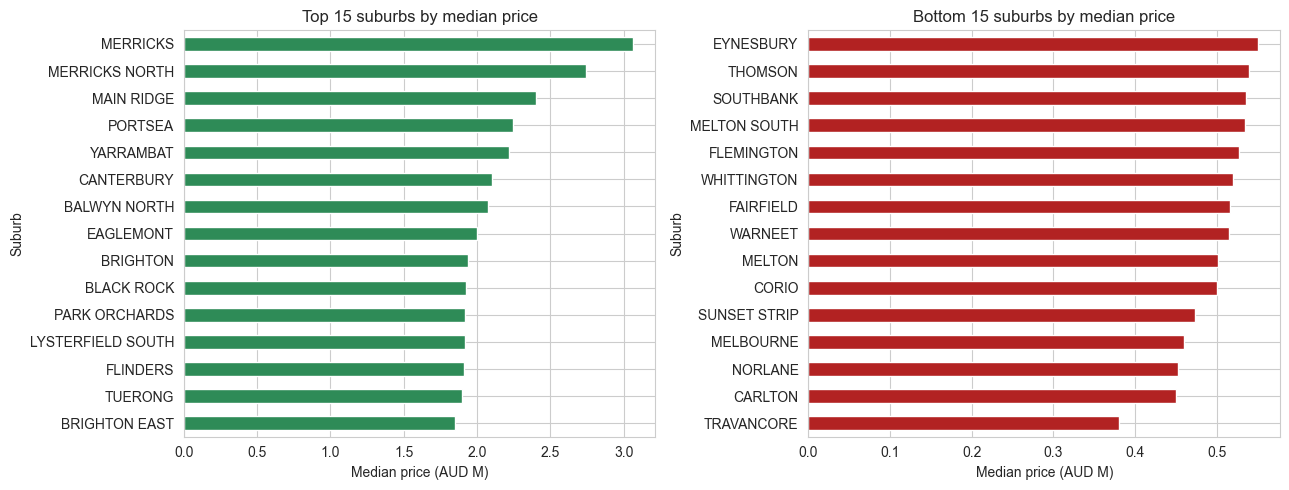

Suburb price range (n >=30): 380,000 to 3,062,500
Ratio top/bottom: 8.1x


In [29]:
sub_med = (sold_priced
           .groupby("Suburb")["Numeric_Price"]
           .agg(["median", "count"])
           .query("count >= 30")
           .sort_values("median"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sub_med.tail(15)["median"].div(1e6).plot(kind="barh", ax=axes[0], color="seagreen")
axes[0].set_title("Top 15 suburbs by median price")
axes[0].set_xlabel("Median price (AUD M)")

sub_med.head(15)["median"].div(1e6).plot(kind="barh", ax=axes[1], color="firebrick")
axes[1].set_title("Bottom 15 suburbs by median price")
axes[1].set_xlabel("Median price (AUD M)")

plt.tight_layout(); plt.show()

print(f"Suburb price range (n >=30): "
      f"{sub_med['median'].min():,.0f} to {sub_med['median'].max():,.0f}")
print(f"Ratio top/bottom: {sub_med['median'].max() / sub_med['median'].min():.1f}x")

Observations on suburb price ranking:

- Range: $380k (TRAVANCORE) to $3.06M (MERRICKS). Top/bottom ratio = 8.1x. Suburb alone explains a huge share of price variation.

- Top 15 dominated by Mornington Peninsula (MERRICKS, MERRICKS NORTH, MAIN RIDGE, PORTSEA, FLINDERS, TUERONG), inner-east (CANTERBURY, BALWYN NORTH, EAGLEMONT, PARK ORCHARDS), and bayside (BRIGHTON, BLACK ROCK, BRIGHTON EAST).

- Bottom 15 dominated by far-west growth (MELTON, MELTON SOUTH, EYNESBURY), Geelong region (THOMSON, NORLANE, CORIO, WHITTINGTON), and a few high-density inner CBD-fringe pockets (SOUTHBANK, CARLTON, MELBOURNE, TRAVANCORE) where apartments dominate the mix.

- The 8.1x ratio confirms Suburb will be a top-3 feature in the ML model. Frequency encoding (as planned) will preserve this signal without leakage.

## 8. Sold vs For Sale Distribution Comparison

The ML model trains on Sold but predicts on For Sale. If the two distributions differ materially, the test-set performance on Sold will overstate real-world performance on For Sale.

I quantify the drift with three checks:

1. Per-feature KS test - compares Sold and For Sale on each numeric feature. Large KS statistic or tiny p-value means the two groups have meaningfully different shapes.

2. Cold-start suburb check - suburbs that appear in For Sale but have no Sold history. The model has no signal for these.

3. Property_Type cold-start - same idea at the type level.

KS test is chosen over a simple median comparison because it captures whole-distribution differences (including tails), is non-parametric, and is robust to skew - which property data is full of.

### 8.1 KS test on numeric features

The Kolmogorov-Smirnov statistic measures the maximum vertical distance between two cumulative distribution functions. Values close to 0 mean similar distributions; values approaching 1 mean disjoint. For datasets this large, even small distributional differences will produce statistically significant p-values, so the absolute KS statistic matters more than significance.

In [30]:
from scipy.stats import ks_2samp

drift_cols = ["Beds", "Baths", "Car_Spaces", "LandSize_sqm",
              "Distance_to_CBD_km", "dist_nearest_train_km",
              "abs_median_income_weekly", "abs_median_age",
              "abs_population", "crime_rate_per_100k"]

rows = []
for c in drift_cols:
    a = df_sold[c].dropna()
    b = df_forsale[c].dropna()
    stat, p = ks_2samp(a, b)
    rows.append({
        "feature":         c,
        "sold_median":     round(a.median(), 2),
        "forsale_median":  round(b.median(), 2),
        "ks_stat":         round(stat, 3),
        "p_value":         f"{p:.2e}",
    })

drift_df = pd.DataFrame(rows).sort_values("ks_stat", ascending=False)
print(drift_df.to_string(index=False))

                 feature  sold_median  forsale_median  ks_stat   p_value
            LandSize_sqm       576.00          400.00    0.241  0.00e+00
          abs_median_age        39.00           35.00    0.237  0.00e+00
      Distance_to_CBD_km        32.98           26.84    0.187  0.00e+00
          abs_population     21274.00        25028.00    0.139  0.00e+00
     crime_rate_per_100k      6609.90         6846.20    0.136  0.00e+00
                    Beds         3.00            4.00    0.128  0.00e+00
   dist_nearest_train_km         0.24            0.20    0.106 9.73e-288
                   Baths         2.00            2.00    0.092 4.01e-215
abs_median_income_weekly       817.00          842.00    0.091 1.08e-212
              Car_Spaces         2.00            2.00    0.056  1.47e-79


Observations on KS drift:

- Largest drifts (KS > 0.13): LandSize (For Sale lots are smaller - 400 vs 576 sqm), median age (younger suburbs - 35 vs 39), Distance_to_CBD (closer in - 26.8 vs 33 km), population, Beds, crime rate. All point to the same story: For Sale concentrates in growth-corridor new-build supply.

- Smallest drifts (KS < 0.10): Baths, income, train distance, Car_Spaces. Stable across the metro.

- All p-values are essentially zero, but with 100k+ rows that is expected. KS statistic itself is what matters.

Implications: the `is_new_build` flag planned in Section 4 explicitly handles the new-build sub-population. Tree models will handle the remaining drift through splits.

### 8.2 Cold-start suburbs

A suburb in For Sale but missing from Sold means the model has no historical signal for it. Frequency encoding will assign such suburbs a value of zero (or the overall mean, depending on the strategy), which is a weak fallback. The count of cold-start suburbs and the share of For Sale rows they cover determines whether this is a marginal concern or a real problem.

In [31]:
sold_subs    = set(df_sold["Suburb"].unique())
forsale_subs = set(df_forsale["Suburb"].unique())

new_in_fs    = forsale_subs - sold_subs
absent_in_fs = sold_subs - forsale_subs
shared       = sold_subs & forsale_subs

print(f"Unique suburbs - Sold:     {len(sold_subs)}")
print(f"Unique suburbs - For Sale: {len(forsale_subs)}")
print(f"Shared (both groups):      {len(shared)}")
print(f"Cold-start (in For Sale, never Sold): {len(new_in_fs)}")
print(f"Absent (in Sold, none For Sale):      {len(absent_in_fs)}")

# How many For Sale rows fall in cold-start suburbs?
n_coldstart_rows = df_forsale["Suburb"].isin(new_in_fs).sum()
print(f"\nFor Sale rows in cold-start suburbs: {n_coldstart_rows:,} "
      f"({n_coldstart_rows / len(df_forsale) * 100:.2f}%)")

if new_in_fs:
    print(f"\nExamples of cold-start suburbs (up to 10): {sorted(list(new_in_fs))[:10]}")

Unique suburbs - Sold:     543
Unique suburbs - For Sale: 527
Shared (both groups):      519
Cold-start (in For Sale, never Sold): 8
Absent (in Sold, none For Sale):      24

For Sale rows in cold-start suburbs: 12 (0.03%)

Examples of cold-start suburbs (up to 10): ['APOLLO BAY', 'BURNLEY', 'CASTELLA', 'FIELDSTONE', 'GRANGEFIELDS', 'INGLISTON', 'LOVELY BANKS', 'MURGHEBOLUC']


Observations on cold-start suburbs:

- 519 of 543 Sold suburbs and 527 For Sale suburbs are shared (95.5% overlap).

- 8 cold-start suburbs in For Sale (APOLLO BAY, BURNLEY, CASTELLA, FIELDSTONE, GRANGEFIELDS, INGLISTON, LOVELY BANKS, MURGHEBOLUC) covering only 12 rows (0.03%). Marginal.

- Frequency encoding will assign these zero; Postcode + Lat/Lng carry the geographic signal. No special fallback needed.

### 8.3 Property_Type cold-start

In [32]:
sold_types = set(df_sold["Property_Type"].unique())
fs_types   = set(df_forsale["Property_Type"].unique())

new_types     = fs_types - sold_types
absent_types  = sold_types - fs_types

print(f"Property_Types only in For Sale (cold-start): {new_types}")
print(f"Property_Types only in Sold (no listings):    {absent_types}")

# Volume of For Sale rows in cold-start Property_Types.
if new_types:
    n_coldstart_types = df_forsale["Property_Type"].isin(new_types).sum()
    print(f"\nFor Sale rows in cold-start Property_Types: {n_coldstart_types:,} "
          f"({n_coldstart_types / len(df_forsale) * 100:.2f}%)")

Property_Types only in For Sale (cold-start): {'Grazing', 'Mixed Farming'}
Property_Types only in Sold (no listings):    {'Livestock'}

For Sale rows in cold-start Property_Types: 3 (0.01%)


Observations on Property_Type cold-start:

- Only Grazing and Mixed Farming exist in For Sale but not Sold (3 rows, 0.01%). All three are negligible agricultural categories that will be grouped into "Other" during ML feature engineering anyway.

- No additional handling needed.

## 9. Summary and Save

I consolidate the findings from Sections 1-8 into a concise list of insights and decisions for the ML notebook, then persist the cleaned data and the decision parameters.

### 9.1 Key insights

1. The dataset has two structurally different groups: 124,820 Sold transactions (with Date and 91.8% with Numeric_Price) and 38,419 For Sale listings (no Date, 86% with asking price).

2. Sold data is heavily concentrated in recent years - 40% of transactions occurred in 2025 alone, and the bulk of data sits in 2023-2026. The early-2000s tail is sparse.

3. Price is heavily right-skewed; log1p(Numeric_Price) is the ML target.

4. Year-over-year median price moves 4-12% per year (non-monotonic, with pullbacks in 2012-2013, 2019, 2023-2024). Month adds 13% peak-to-trough seasonality. Year and Month must be features.

5. Different Property_Types inflate at different rates - the House-Apartment gap widens over time. Tree models will capture this Year x Property_Type interaction; the Linear baseline will not.

6. Strongest price drivers: Baths (corr 0.43), Beds (0.37), median age (0.31), Car_Spaces (0.29), LandSize (0.24), median income (0.24). Property_Type and Suburb are also strong (suburb price range is 8.1x top to bottom).

7. Beds-Baths correlation is 0.76 - Linear baseline needs Ridge regularization.

8. Largest Sold vs For Sale drift: For Sale concentrates in growth-corridor new-build supply (smaller lots, younger demographics, closer to CBD, heavy New House & Land share - 27% vs 0.3%). An `is_new_build` flag will be added in the ML notebook.

9. Cold-start risk is marginal: only 8 suburbs (12 rows, 0.03%) and 2 Property_Types (3 rows, 0.01%) appear in For Sale but not Sold.

### 9.2 Decisions exported for the ML notebook

- Target: log1p(Numeric_Price).

- Split: time-based 70/15/15 on sorted Date_parsed.

- Time features: Year and Month as plain integers.

- Categorical encoding: Property_Type one-hot, Suburb frequency-encoded, rare types grouped into "Other".

- Engineered features: is_land (already built), out_of_metro (already built), is_new_build (to build).

- Imputation: median per Property_Type for LandSize NaN; median for Beds/Baths NaN where the row is non-land; median for crime_rate_per_100k NaN. Fit on train fold only.

- At For Sale inference: inject Year = 2026, Month = 5 to reflect the snapshot's current market level.

In [33]:
from pathlib import Path

# Save cleaned data
out = pd.concat([df_sold, df_forsale], ignore_index=True)

out_dir = Path("report_data")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "cleaned_data.parquet"

out.to_parquet(out_path, index=False)

print(f"Saved cleaned data -> {out_path}")
print(f"  Total rows: {len(out):,}")
print(f"  Sold:       {(out['Status'] == 'Sold').sum():,}")
print(f"  For Sale:   {(out['Status'] == 'For Sale').sum():,}")
print(f"  Columns:    {len(out.columns)}")
print(f"  Size on disk: {out_path.stat().st_size / 1e6:.1f} MB")

Saved cleaned data -> report_data\cleaned_data.parquet
  Total rows: 163,239
  Sold:       124,820
  For Sale:   38,419
  Columns:    32
  Size on disk: 11.7 MB


In [34]:
# Persist the EDA decisions as a JSON the ML notebook will load.
# This is the single source of truth for cleaning/encoding parameters so the two notebooks stay in sync.
decisions = {
    "data_snapshot_date": "2026-05-02",

    # Outlier handling
    "land_property_types": sorted(LAND_TYPES),
    "apt_like_types":      sorted(APT_LIKE),
    "rural_large_types":   sorted(RURAL_LARGE),
    "residential_dense_types": sorted(RESIDENTIAL_DENSE),
    "price_floor":   50_000,
    "price_ceiling": 20_000_000,
    "landsize_caps_by_type": {k: round(v, 0) for k, v in land_caps.items()},
    "metro_envelope": {"lat": [-38.6, -37.4], "lon": [144.4, 145.7]},

    # ML setup
    "target_transform": "log1p",
    "split_strategy":   "time_based",
    "split_ratios":     {"train": 0.70, "val": 0.15, "test": 0.15},
    "inference_year":   2026,
    "inference_month":  5,

    # Rare Property_Type categories to group as "Other" in ML feature engineering
    "rare_property_types": rare_types.index.tolist(),

    # New-build Property_Type categories to flag with is_new_build
    "new_build_types": ["New House & Land", "New Apartments / Off the Plan",
                        "New Home Designs", "New land"],

    # Rationale
    "rationale_year_month": (
        "Sold prices show 4-12% YoY changes and 13% peak-to-trough seasonality. "
        "Year and Month let the model learn this. At For Sale inference, "
        "current Year/Month are injected to obtain today-priced estimates."
    ),
}

decisions_path = "report_data/eda_decisions.json"
with open(decisions_path, "w") as f:
    json.dump(decisions, f, indent=2)

print(f"Saved decisions -> {decisions_path}")

Saved decisions -> report_data/eda_decisions.json


The EDA report is complete. The next notebook (`ml_report.ipynb` and `ml_report.html`) will:

1. Load `cleaned_data.parquet` and `eda_decisions.json`.

2. Engineer features including is_new_build, rare-type grouping, and frequency encoding for Suburb.

3. Apply a time-based 70/15/15 split on sorted Date_parsed.

4. Train Linear Regression, Random Forest, and XGBoost; tune hyperparameters on the validation fold.

5. Select the best model, evaluate on the test fold, retrain on full Sold, and predict For Sale prices with Year = 2026, Month = 5.

6. Save model artifacts and predictions for the FastAPI dashboard.